# Secondary metabolites and liquid aroma data review

This notebook visualizes the data now available for nitrogen fractions, pyruvic acid, acetaldehyde, acetic acid, and liquid aroma measurements. The purpose is model-structure selection, not parameter estimation.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'results').exists() and (ROOT / 'fermentation_model').exists():
    ROOT = ROOT / 'fermentation_model'
RESULTS = ROOT / 'results/secondary_metabolite_data_review'
summary = pd.read_csv(RESULTS / 'observation_summary.csv')
batch_summary = pd.read_csv(RESULTS / 'batch_variable_summary.csv')
summary

,medium,variable,n_obs,n_batches,min,median,max
0,historical_vl3,YAN_mg_l,134,8,10.000000,19.420000,164.520000
1,historical_vl3,PAN_mg_l,134,8,9.000000,16.000000,101.000000
2,historical_vl3,NH4_mg_l,134,8,0.000000,3.000000,86.000000
3,historical_vl3,pyruvic_acid,136,8,18.000000,46.500000,98.000000
4,historical_vl3,pyruvic_acid_2,13,1,0.000000,12.000000,36.000000
5,historical_vl3,acetaldehyde,114,6,129.000000,205.500000,288.000000
6,historical_vl3,acetic_acid,0,0,NaN,NaN,NaN
7,historical_vl3,DO_mg_l,0,0,NaN,NaN,NaN
8,historical_vl3,benzyl_alcohol_total,50,8,0.023633,0.036386,0.049371
9,historical_vl3,benzaldehyde_total,50,8,0.001407,0.003640,0.032135


## Observation availability

Use this table to decide which variables can support dynamic calibration and which should remain diagnostic outputs or regularized states.

In [2]:
display(summary.sort_values(['medium', 'variable']))
availability = summary.pivot(index='variable', columns='medium', values='n_obs').fillna(0).astype(int)
display(availability)
display(batch_summary.head(20))

,medium,variable,n_obs,n_batches,min,median,max
7,historical_vl3,DO_mg_l,0,0,NaN,NaN,NaN
2,historical_vl3,NH4_mg_l,134,8,0.000000,3.000000,86.000000
1,historical_vl3,PAN_mg_l,134,8,9.000000,16.000000,101.000000
0,historical_vl3,YAN_mg_l,134,8,10.000000,19.420000,164.520000
5,historical_vl3,acetaldehyde,114,6,129.000000,205.500000,288.000000
6,historical_vl3,acetic_acid,0,0,NaN,NaN,NaN
9,historical_vl3,benzaldehyde_total,50,8,0.001407,0.003640,0.032135
8,historical_vl3,benzyl_alcohol_total,50,8,0.023633,0.036386,0.049371
15,historical_vl3,ethyl_acetate_total,50,8,1.774577,7.729766,13.927214
10,historical_vl3,ethyl_decanoate_total,50,8,0.000000,0.004757,0.029606


medium,historical_vl3,natural,synthetic
variable,,,
DO_mg_l,0,32,0
NH4_mg_l,134,91,83
PAN_mg_l,134,91,83
YAN_mg_l,134,91,83
acetaldehyde,114,79,0
acetic_acid,0,50,0
benzaldehyde_total,50,0,0
benzyl_alcohol_total,50,0,0
ethyl_acetate_total,50,0,0


,medium,batch,n_time,t_max_h,n_YAN_mg_l,first_YAN_mg_l,last_YAN_mg_l,max_YAN_mg_l,n_PAN_mg_l,first_PAN_mg_l,...,last_ethyl_octanoate_total,max_ethyl_octanoate_total,n_phenylethyl_acetate_total,first_phenylethyl_acetate_total,last_phenylethyl_acetate_total,max_phenylethyl_acetate_total,n_ethyl_acetate_total,first_ethyl_acetate_total,last_ethyl_acetate_total,max_ethyl_acetate_total
0,historical_vl3,25026,24,138.0,11,154.50,18.00,154.50,11,93.0,...,0.141056,0.144663,5,0.006356,0.161175,0.204965,5,1.774577,8.904113,13.927214
1,historical_vl3,25027,32,186.0,13,162.50,19.92,162.50,13,101.0,...,0.095492,0.095492,5,0.009810,0.153142,0.176096,5,1.793548,11.189578,11.189578
2,historical_vl3,25085,35,216.0,17,93.34,19.20,93.34,17,63.0,...,0.060123,0.060123,5,0.014899,0.114895,0.114895,5,2.063340,10.752416,10.752416
3,historical_vl3,25086,35,216.0,17,92.70,17.38,92.70,17,64.0,...,0.046756,0.046756,5,0.024970,0.084287,0.089620,5,2.152905,7.906658,7.906658
4,historical_vl3,25150,30,174.0,14,94.24,10.00,94.24,14,68.0,...,0.052452,0.052452,6,0.018375,0.093484,0.096125,6,2.136861,8.508378,8.508378
5,historical_vl3,25151,30,174.0,14,90.78,11.00,90.78,14,67.0,...,0.045336,0.045336,6,0.014123,0.087293,0.101586,6,2.178099,6.994612,7.503539
6,historical_vl3,25170,63,372.0,24,98.42,30.28,152.78,24,73.0,...,0.082987,0.086510,10,0.017027,0.106584,0.109043,10,4.596342,10.412726,11.903406
7,historical_vl3,25171,63,372.0,24,96.60,19.46,164.52,24,72.0,...,0.049305,0.072553,8,0.000217,0.025876,0.093821,8,2.968266,12.849770,12.924789
8,natural,LAB004,14,163.0,13,230.76,28.46,230.76,13,93.0,...,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN
9,natural,LAB005,14,163.0,13,227.30,32.28,227.30,13,92.0,...,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN


## Immediate interpretation

- Pyruvate has enough repeated trajectories to be considered a transient state.
- Acetaldehyde is available in natural and historical batches, but not synthetic, so it is useful for validation and regularized fitting rather than unconstrained expansion.
- Acetic acid is currently natural-only, so it should enter as a low-dimensional auxiliary state.
- Liquid aromas are currently historical-only in this merged review; new natural aroma data should be appended before model-based aroma DOE.
- PAN and ammonium have distinct behavior and should be retained as separate nitrogen pools in the next model version.

## YAN component consistency

The loader keeps total `YAN`, `PAN`, and `NH4` separately. The residual `YAN - (PAN + NH4)` is useful for detecting unit, assay, or preprocessing differences.

In [3]:
yan = pd.read_csv(RESULTS / 'yan_component_consistency.csv')
yan.dropna(subset=['YAN_component_residual_mg_l']).groupby('medium')['YAN_component_residual_mg_l'].describe()

,count,mean,std,min,25%,50%,75%,max
medium,,,,,,,,
historical_vl3,134.0,-2.360149,3.930402,-15.48,-3.06,-0.54,0.00000,0.0
natural,91.0,-8.119780,11.208811,-30.96,-19.44,-0.36,0.00000,0.0
synthetic,83.0,-23.421693,17.520102,-54.00,-43.00,-16.00,-6.00005,0.0


## Per-batch plots

The following figures show sugars, biomass, nitrogen fractions, secondary metabolites, ethanol/glycerol, and liquid aromas by batch.

secondary_historical_vl3_25026.png


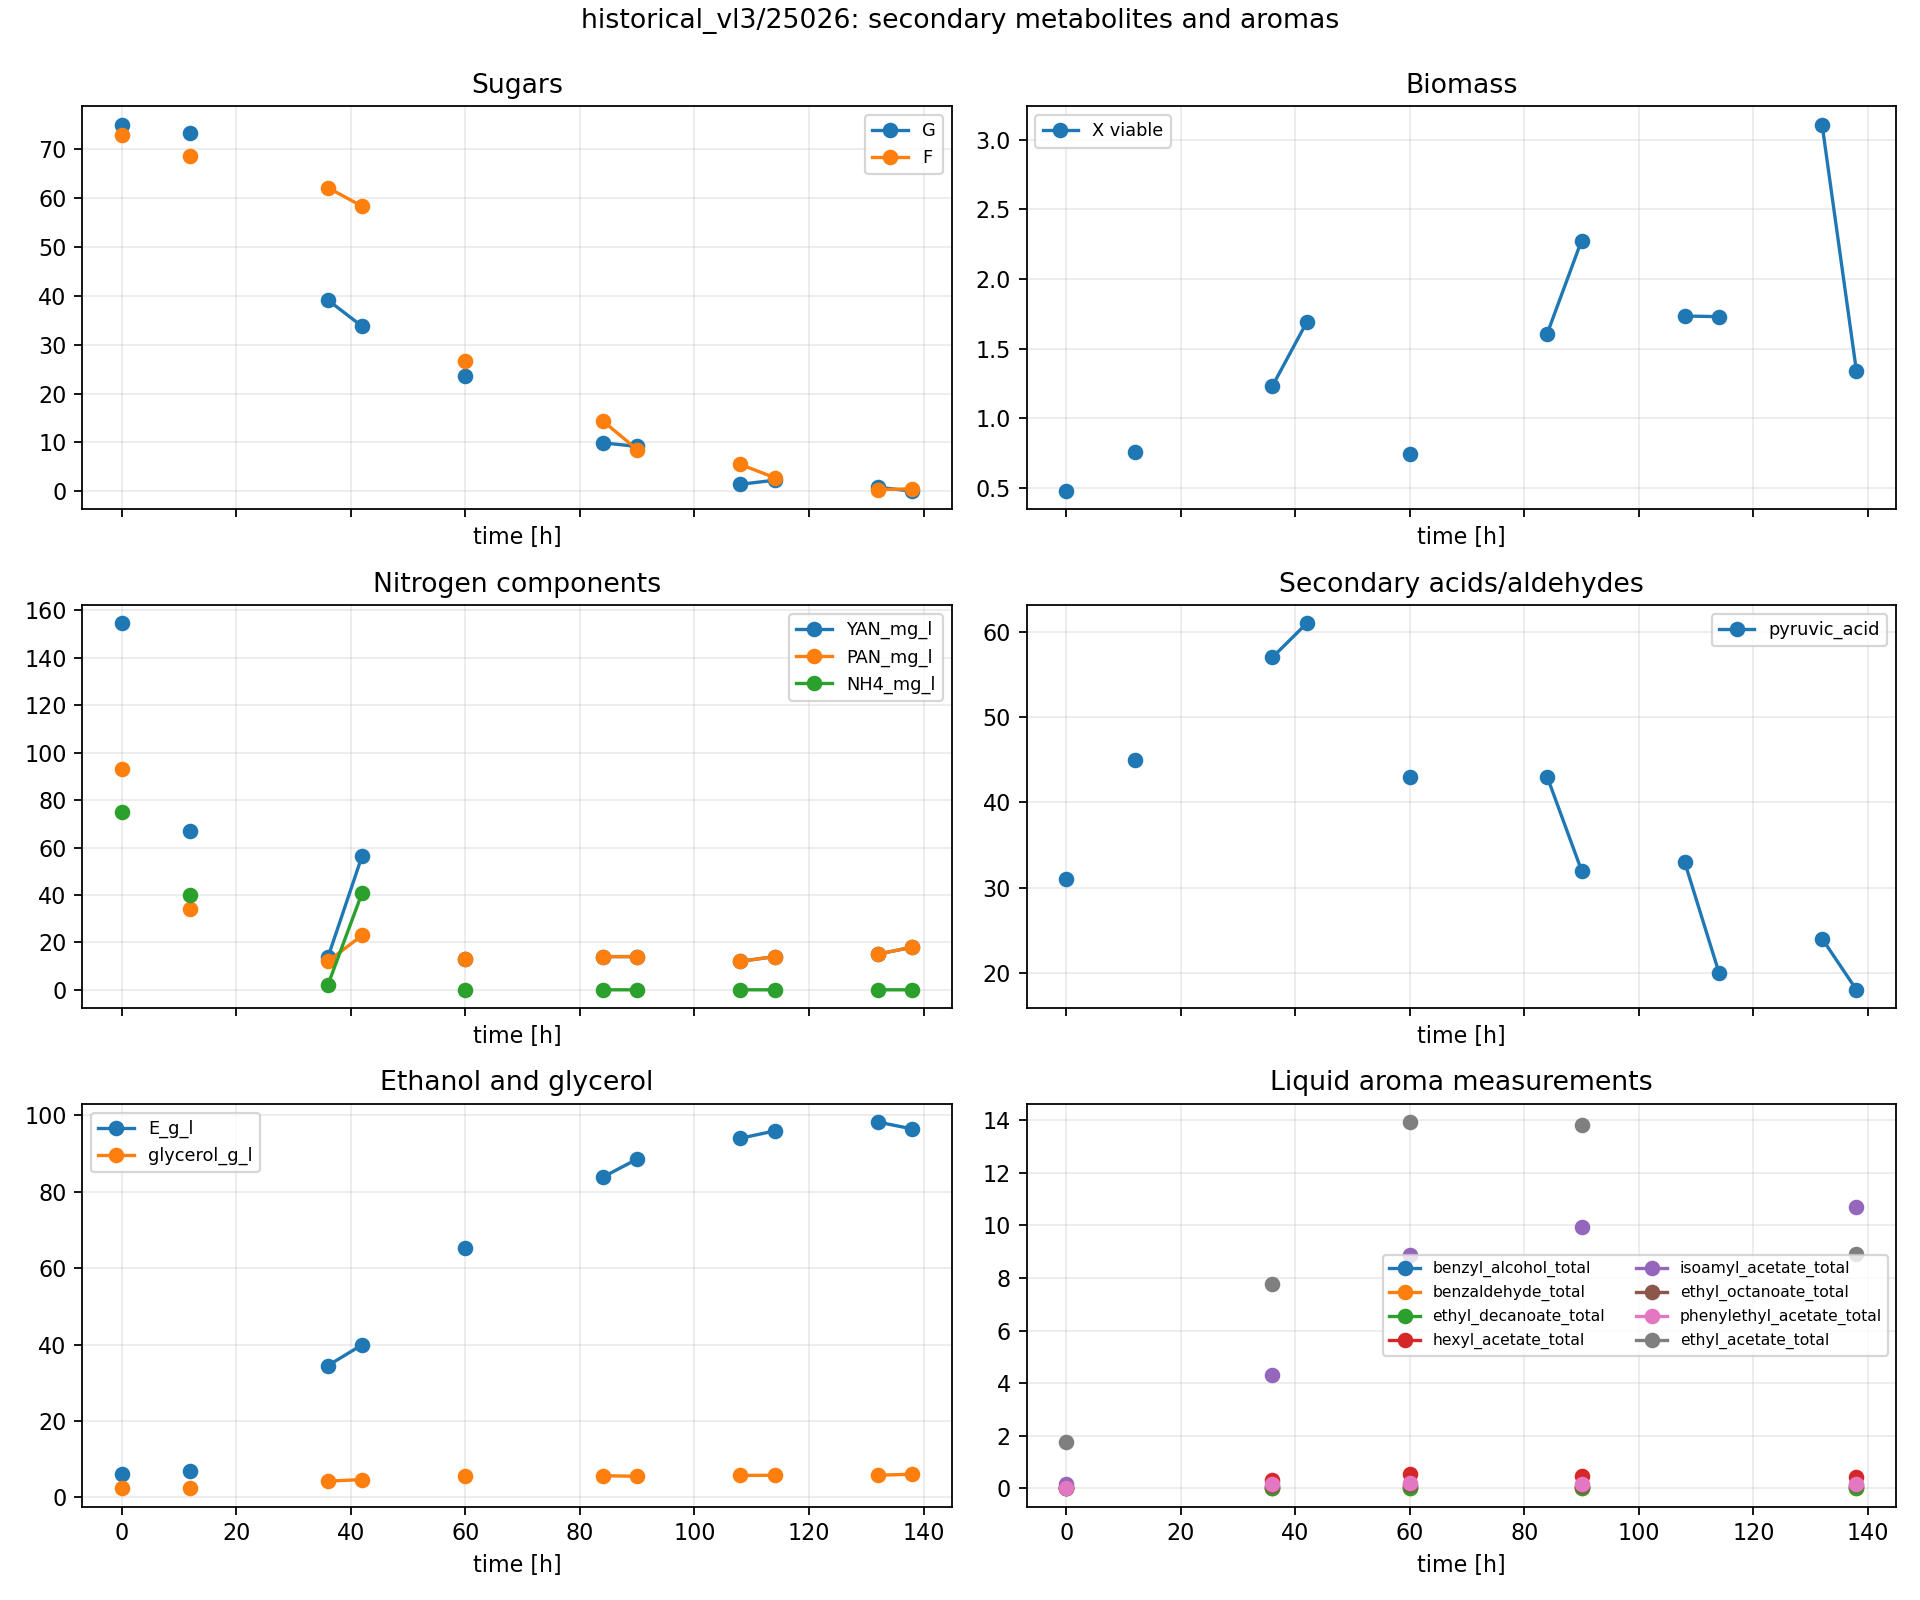

secondary_historical_vl3_25027.png


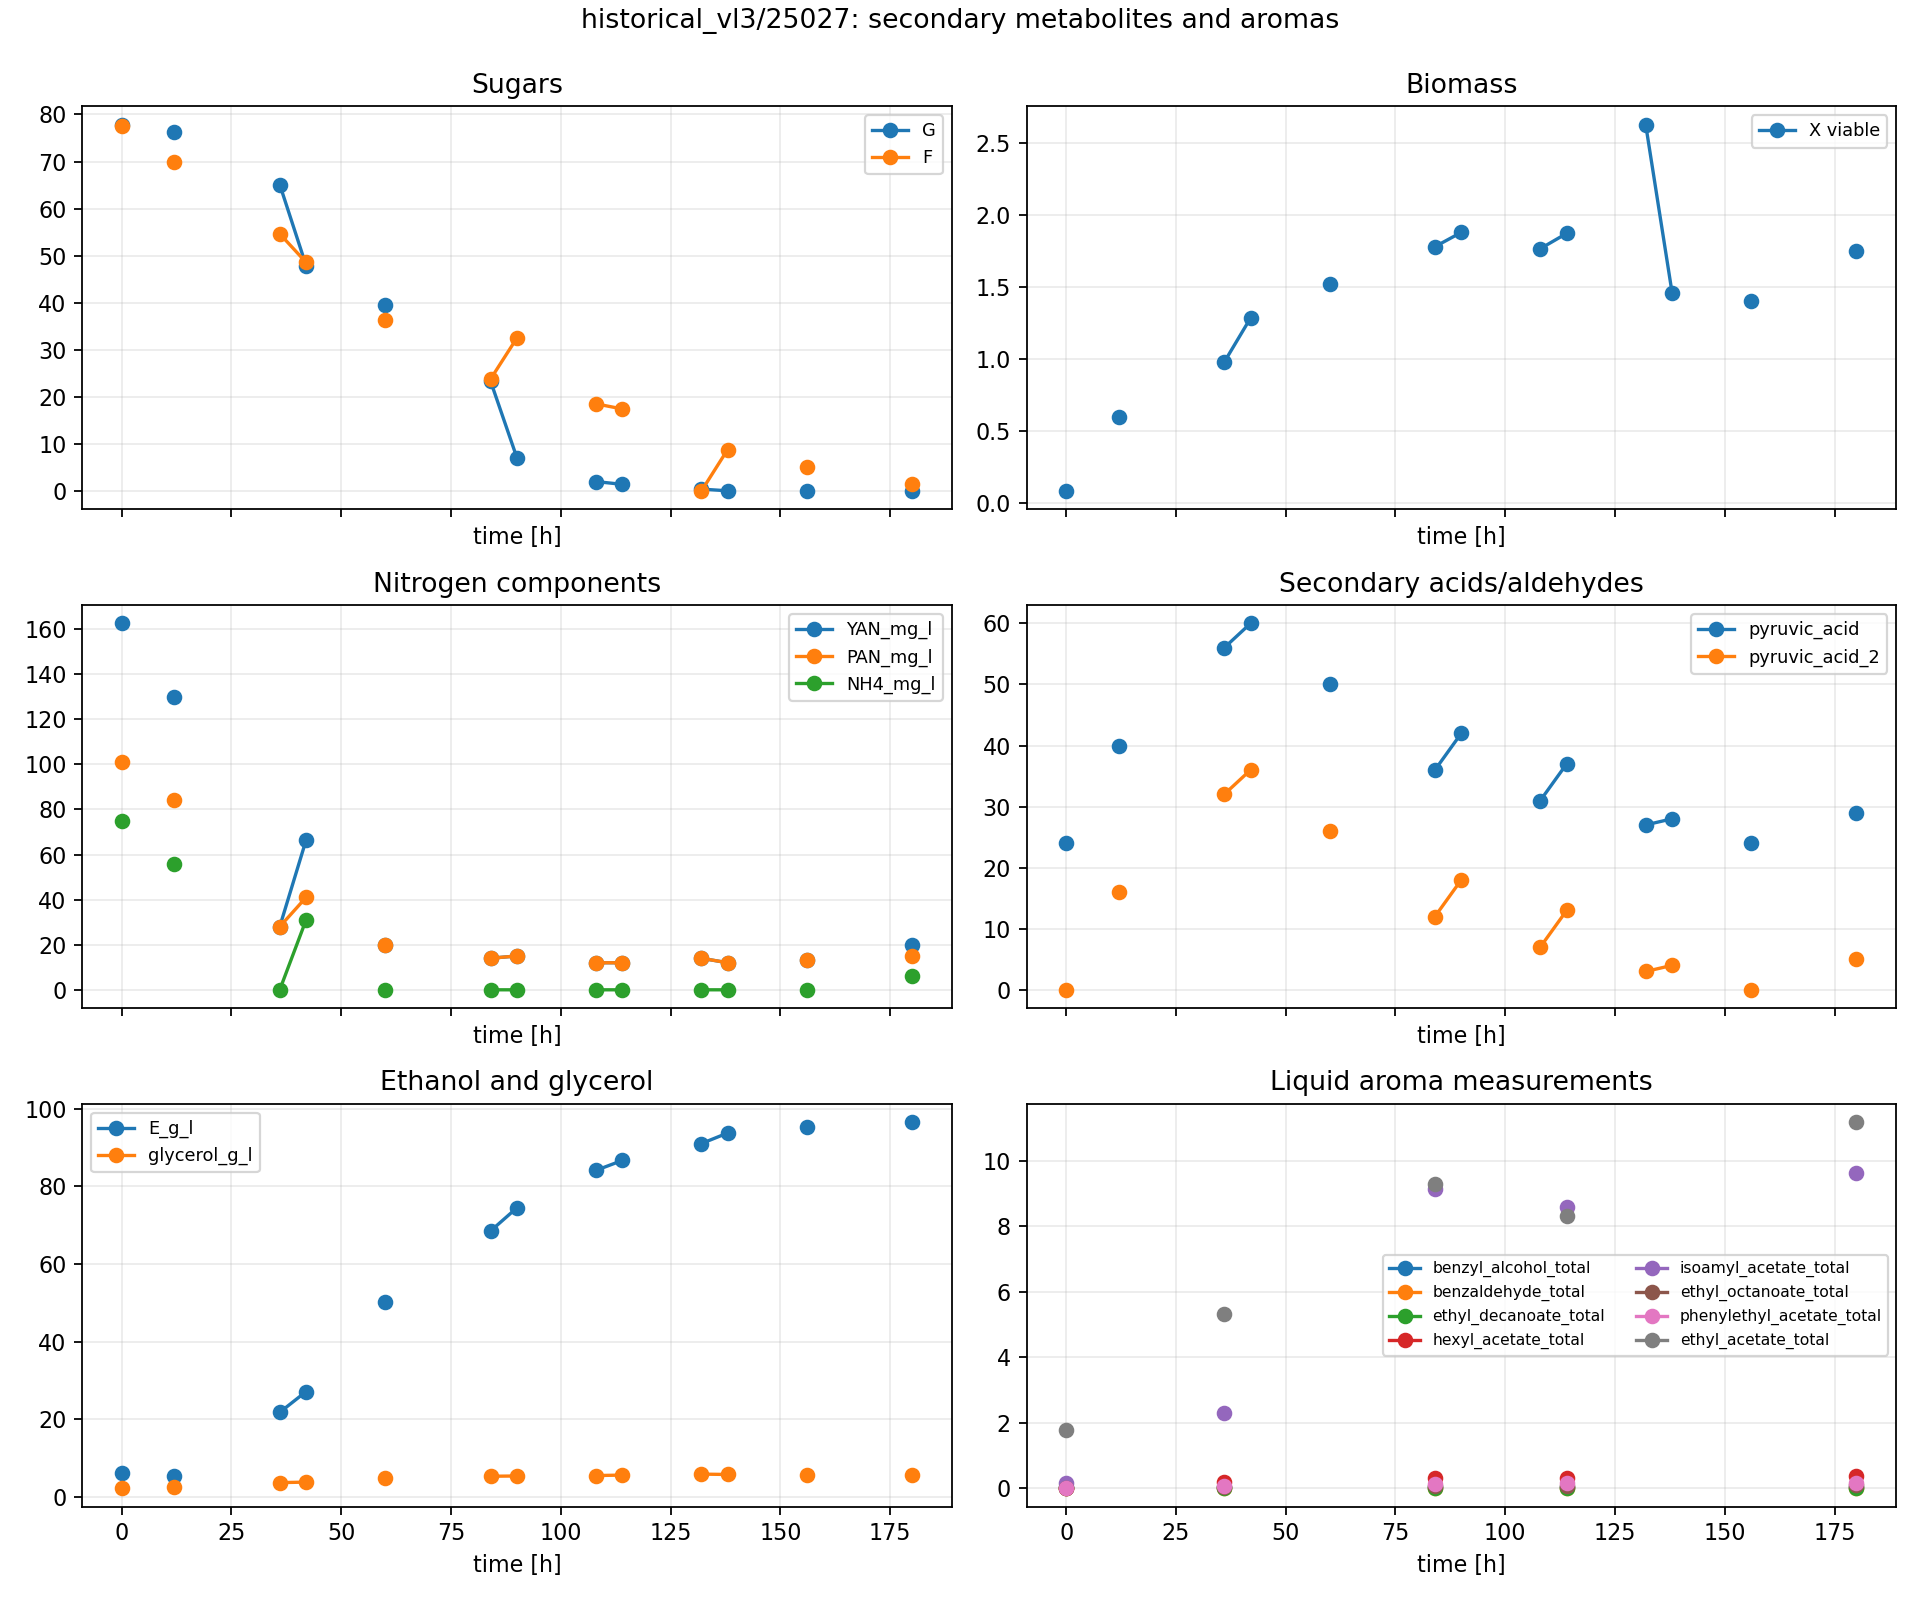

secondary_historical_vl3_25085.png


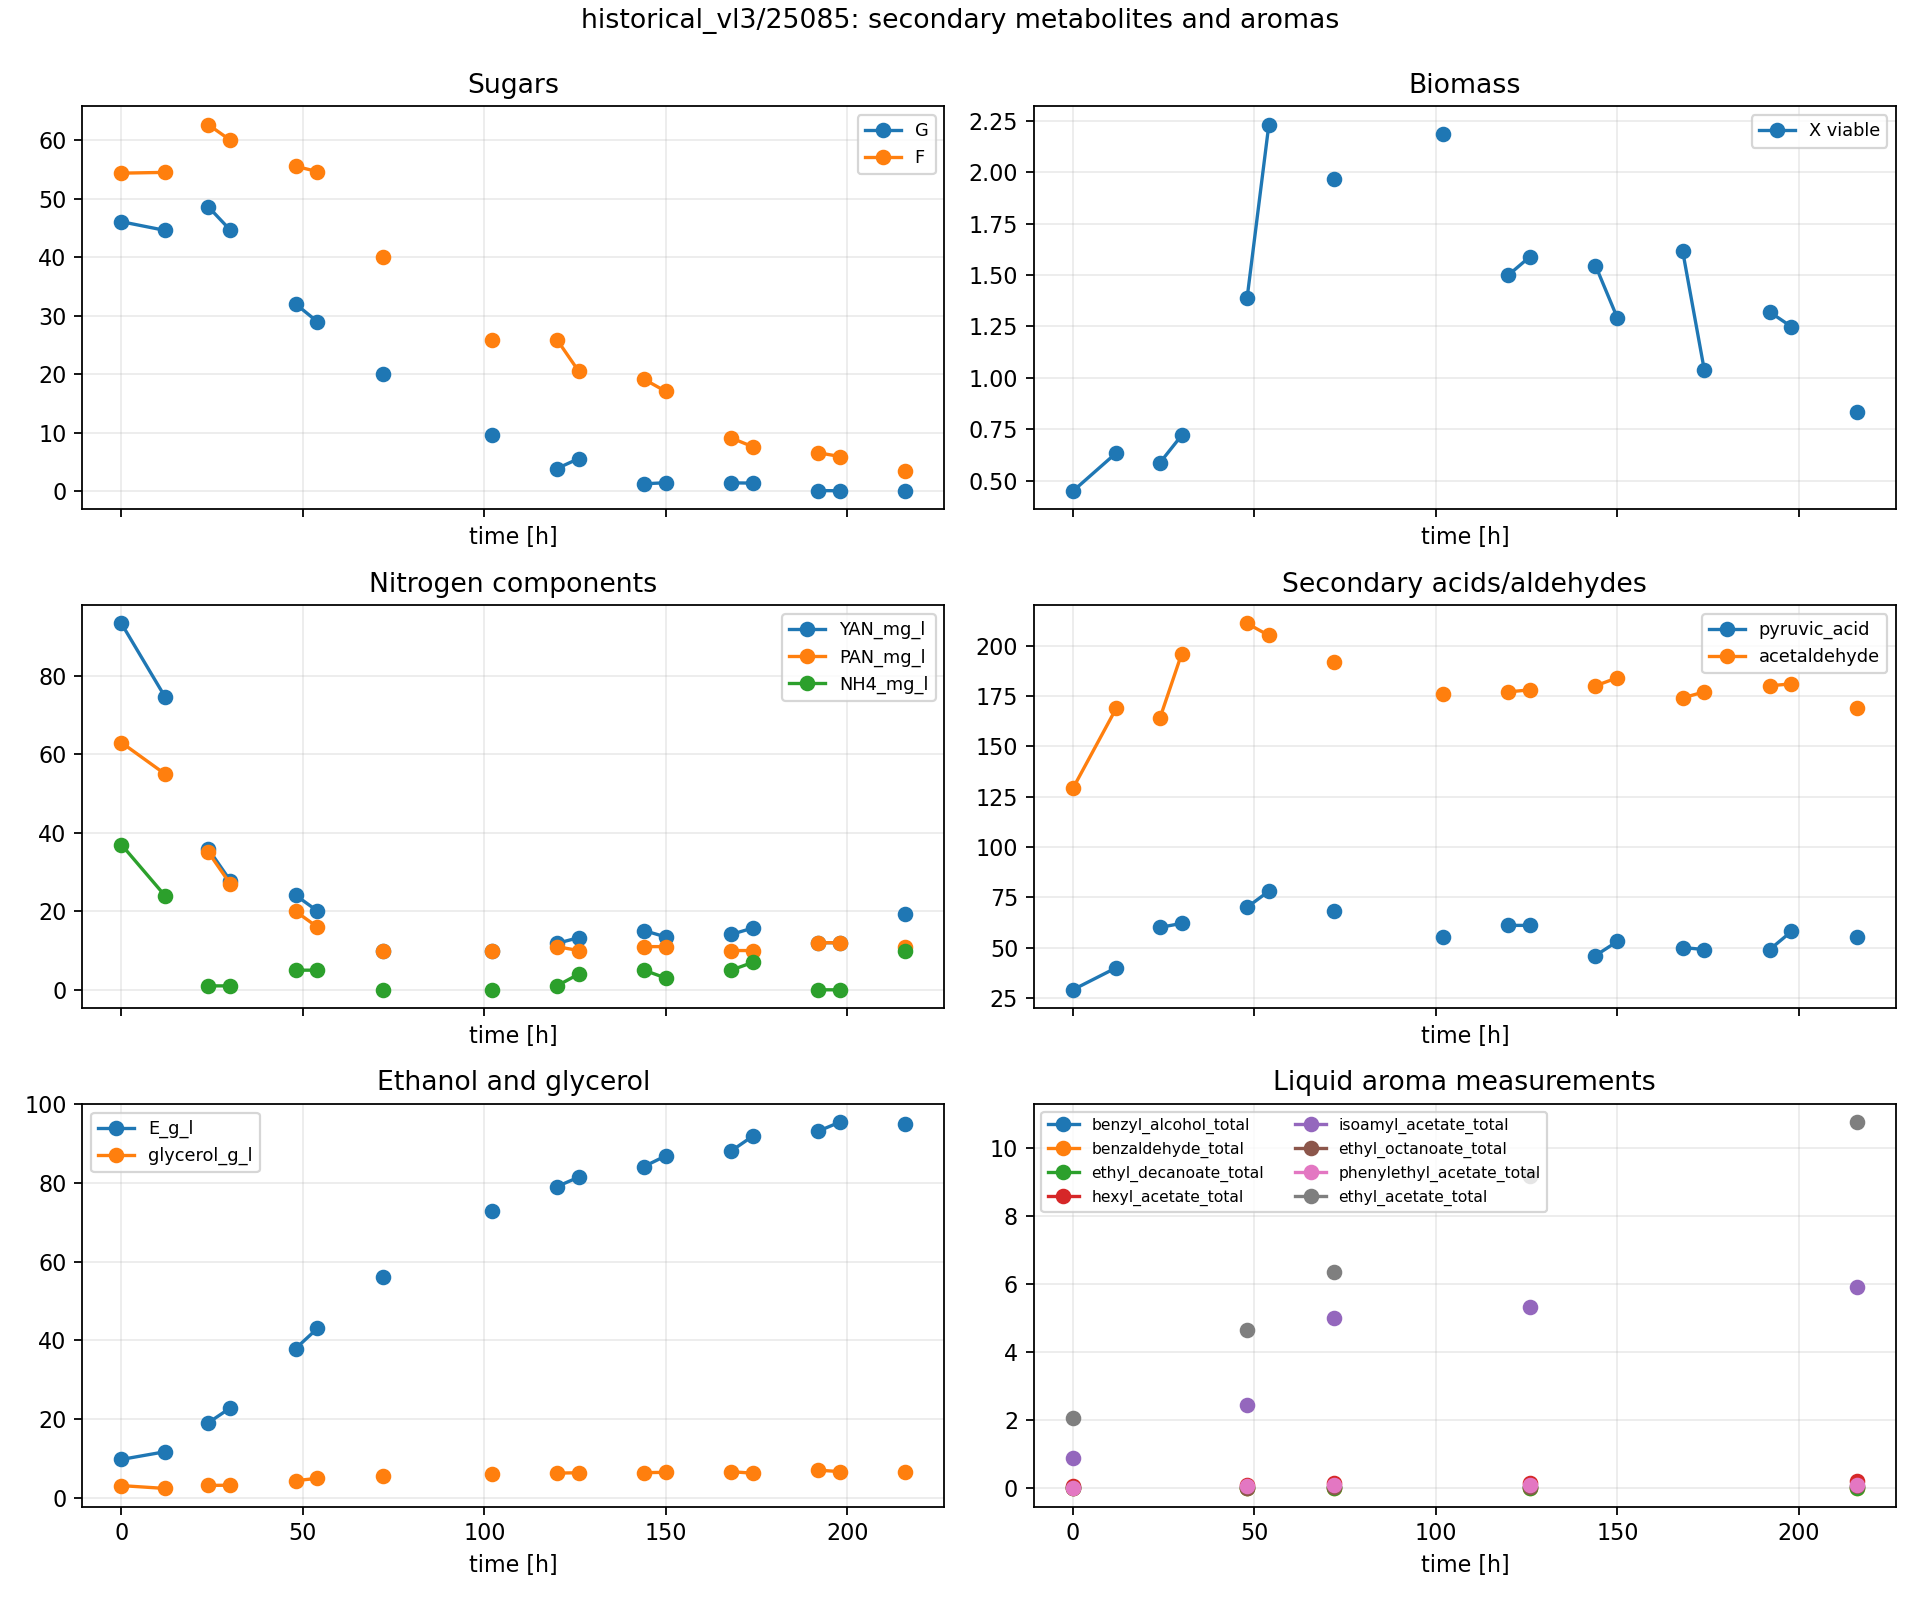

secondary_historical_vl3_25086.png


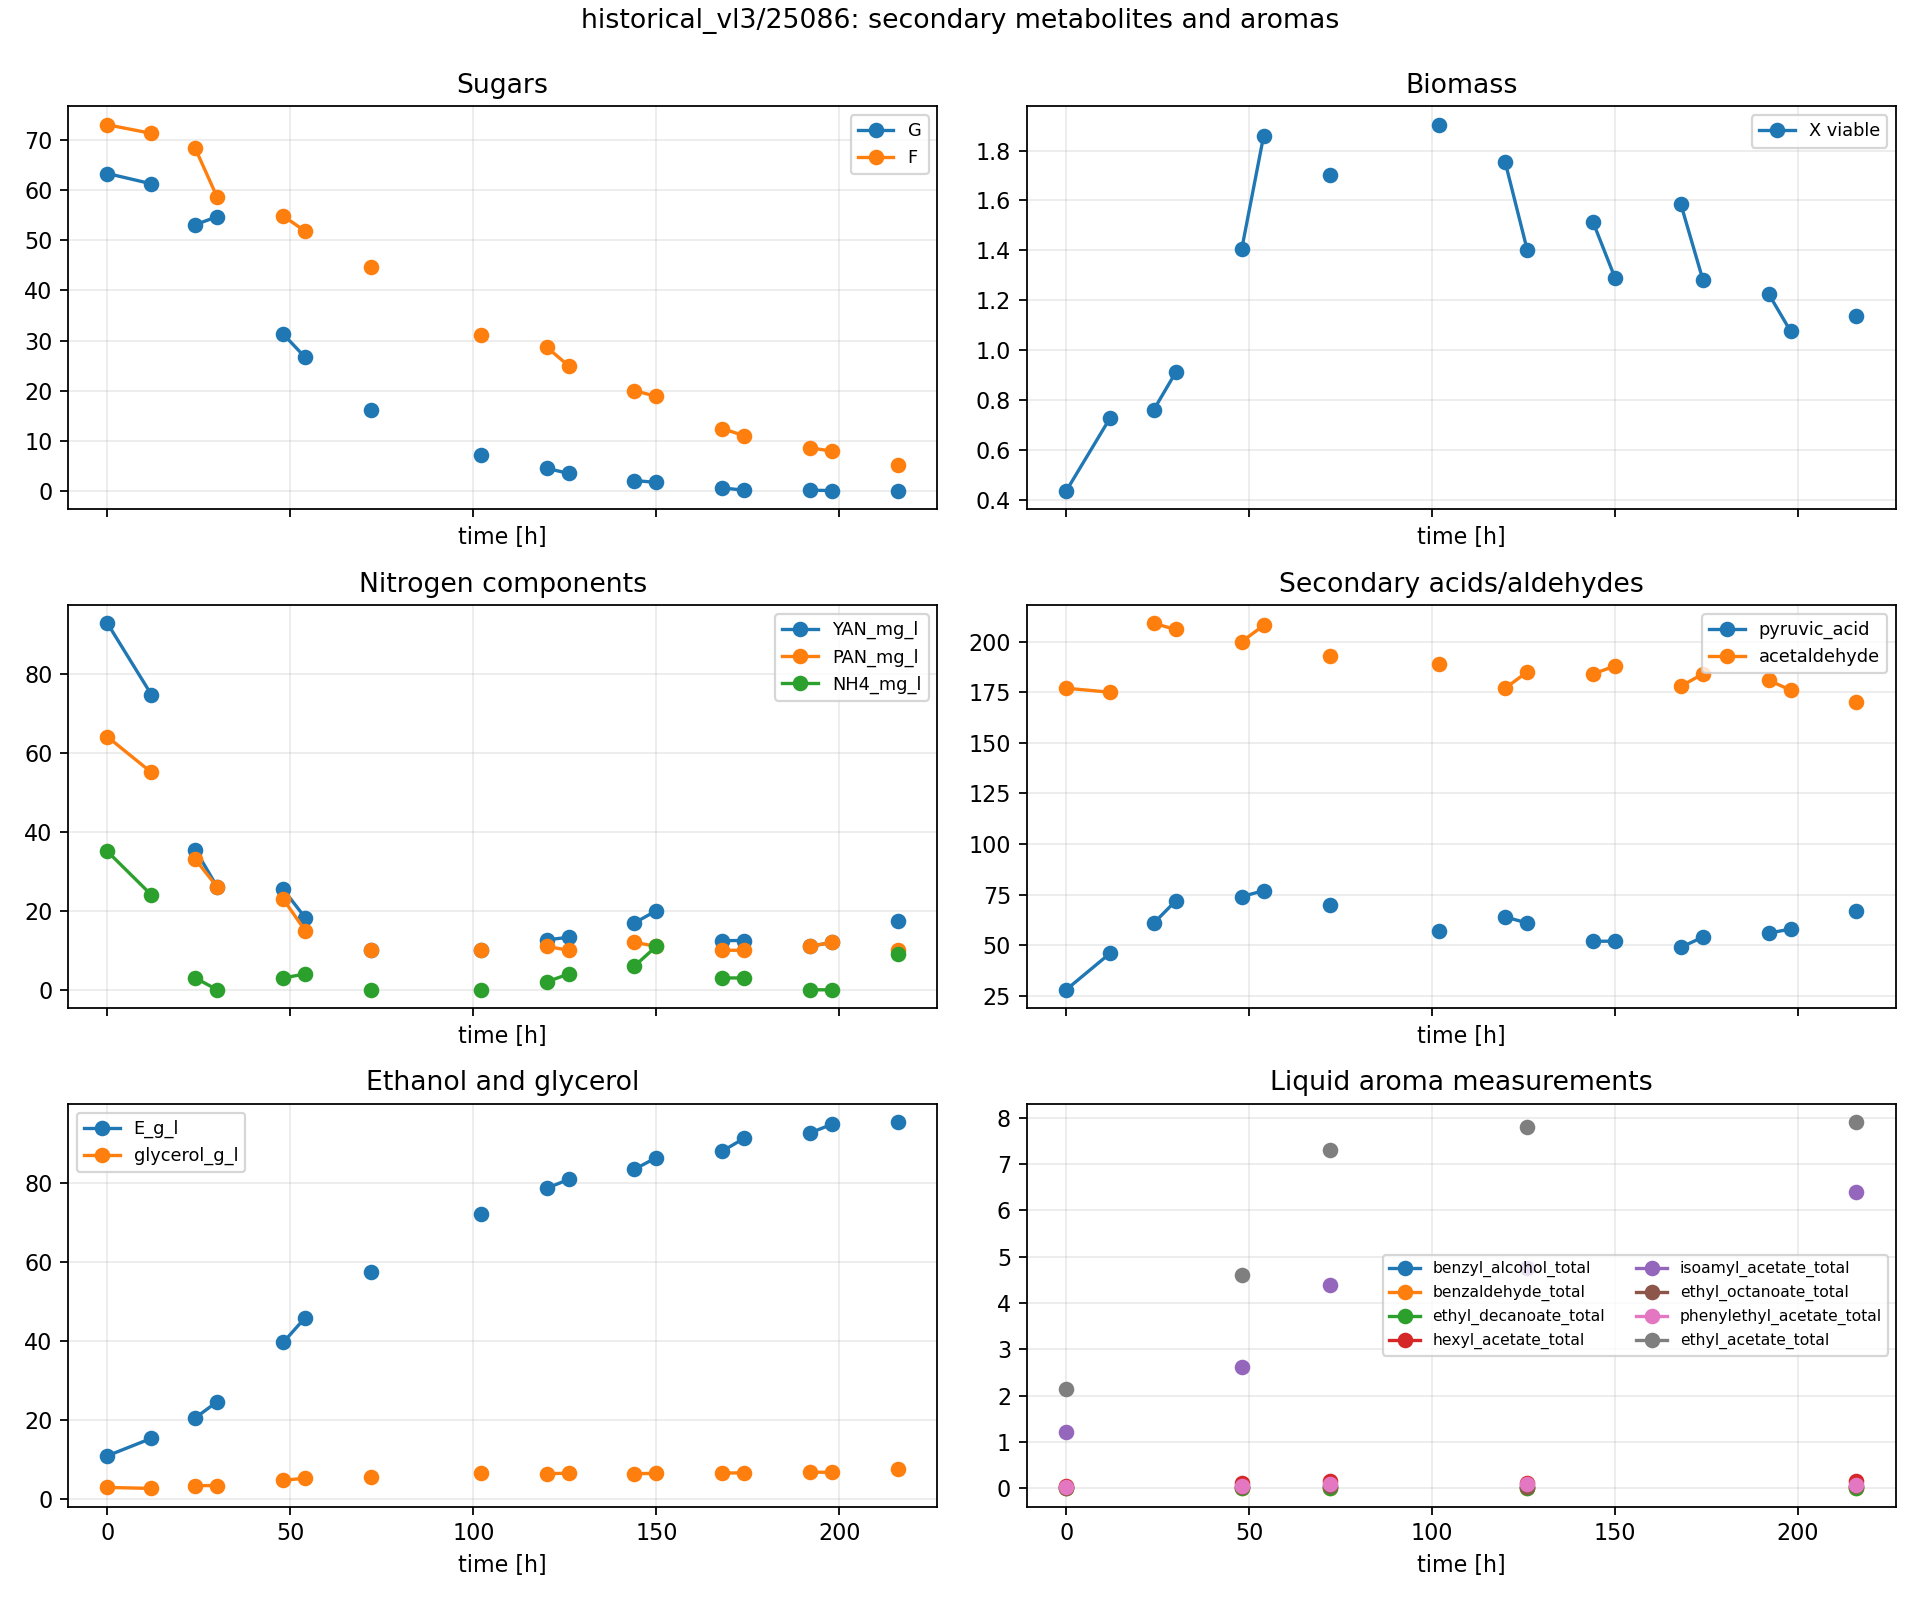

secondary_historical_vl3_25150.png


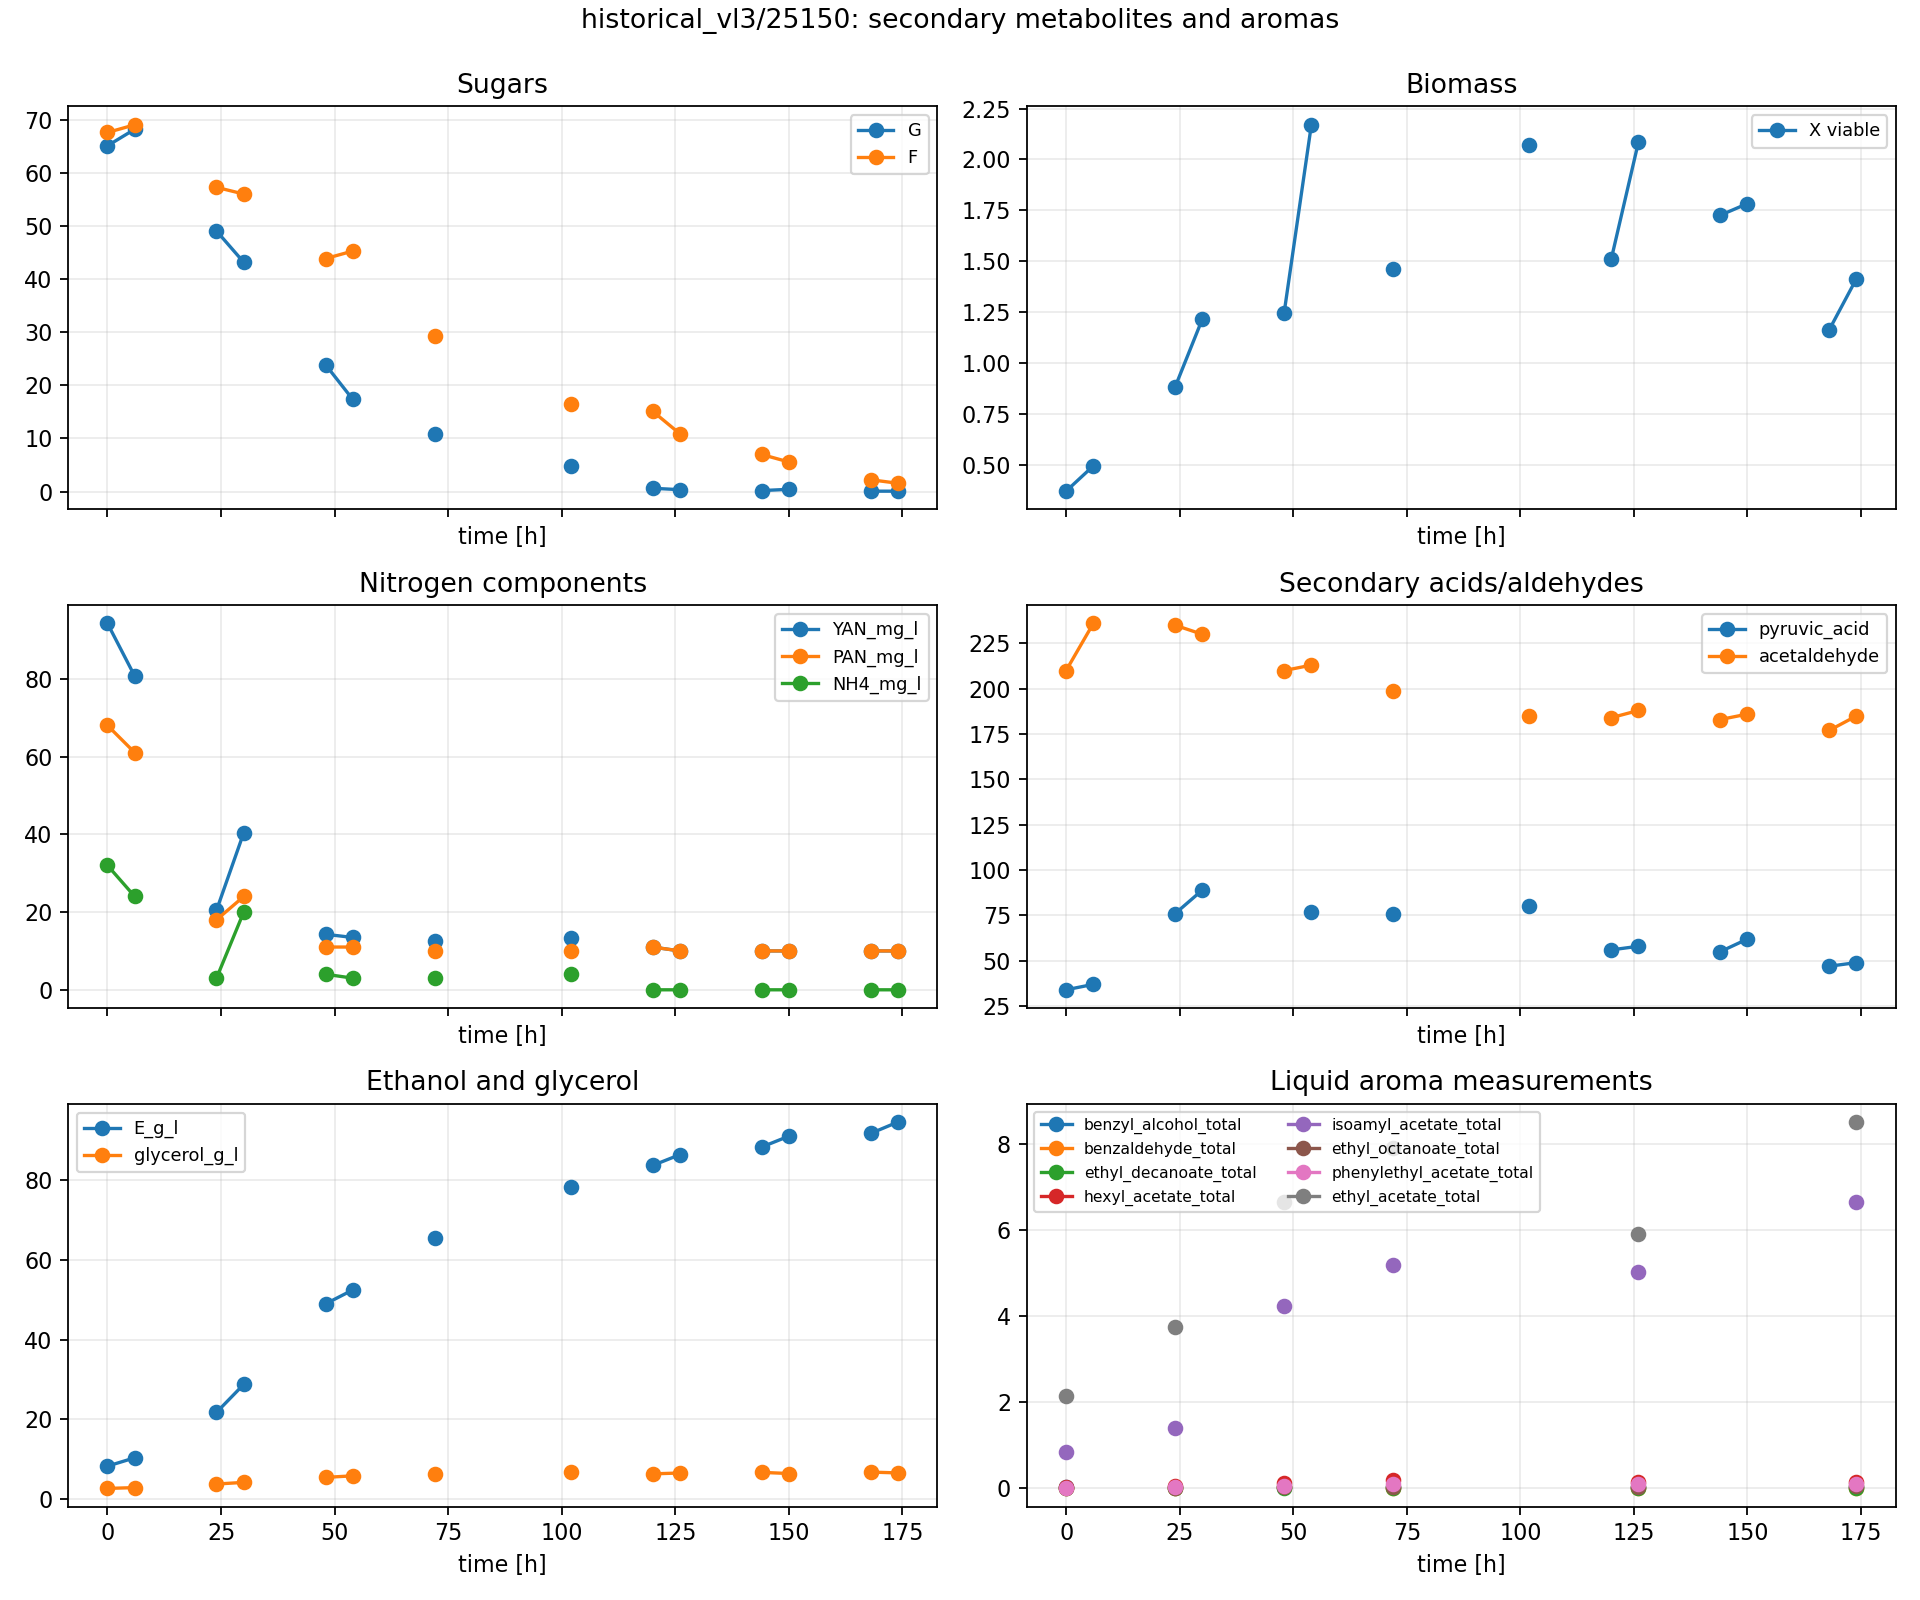

secondary_historical_vl3_25151.png


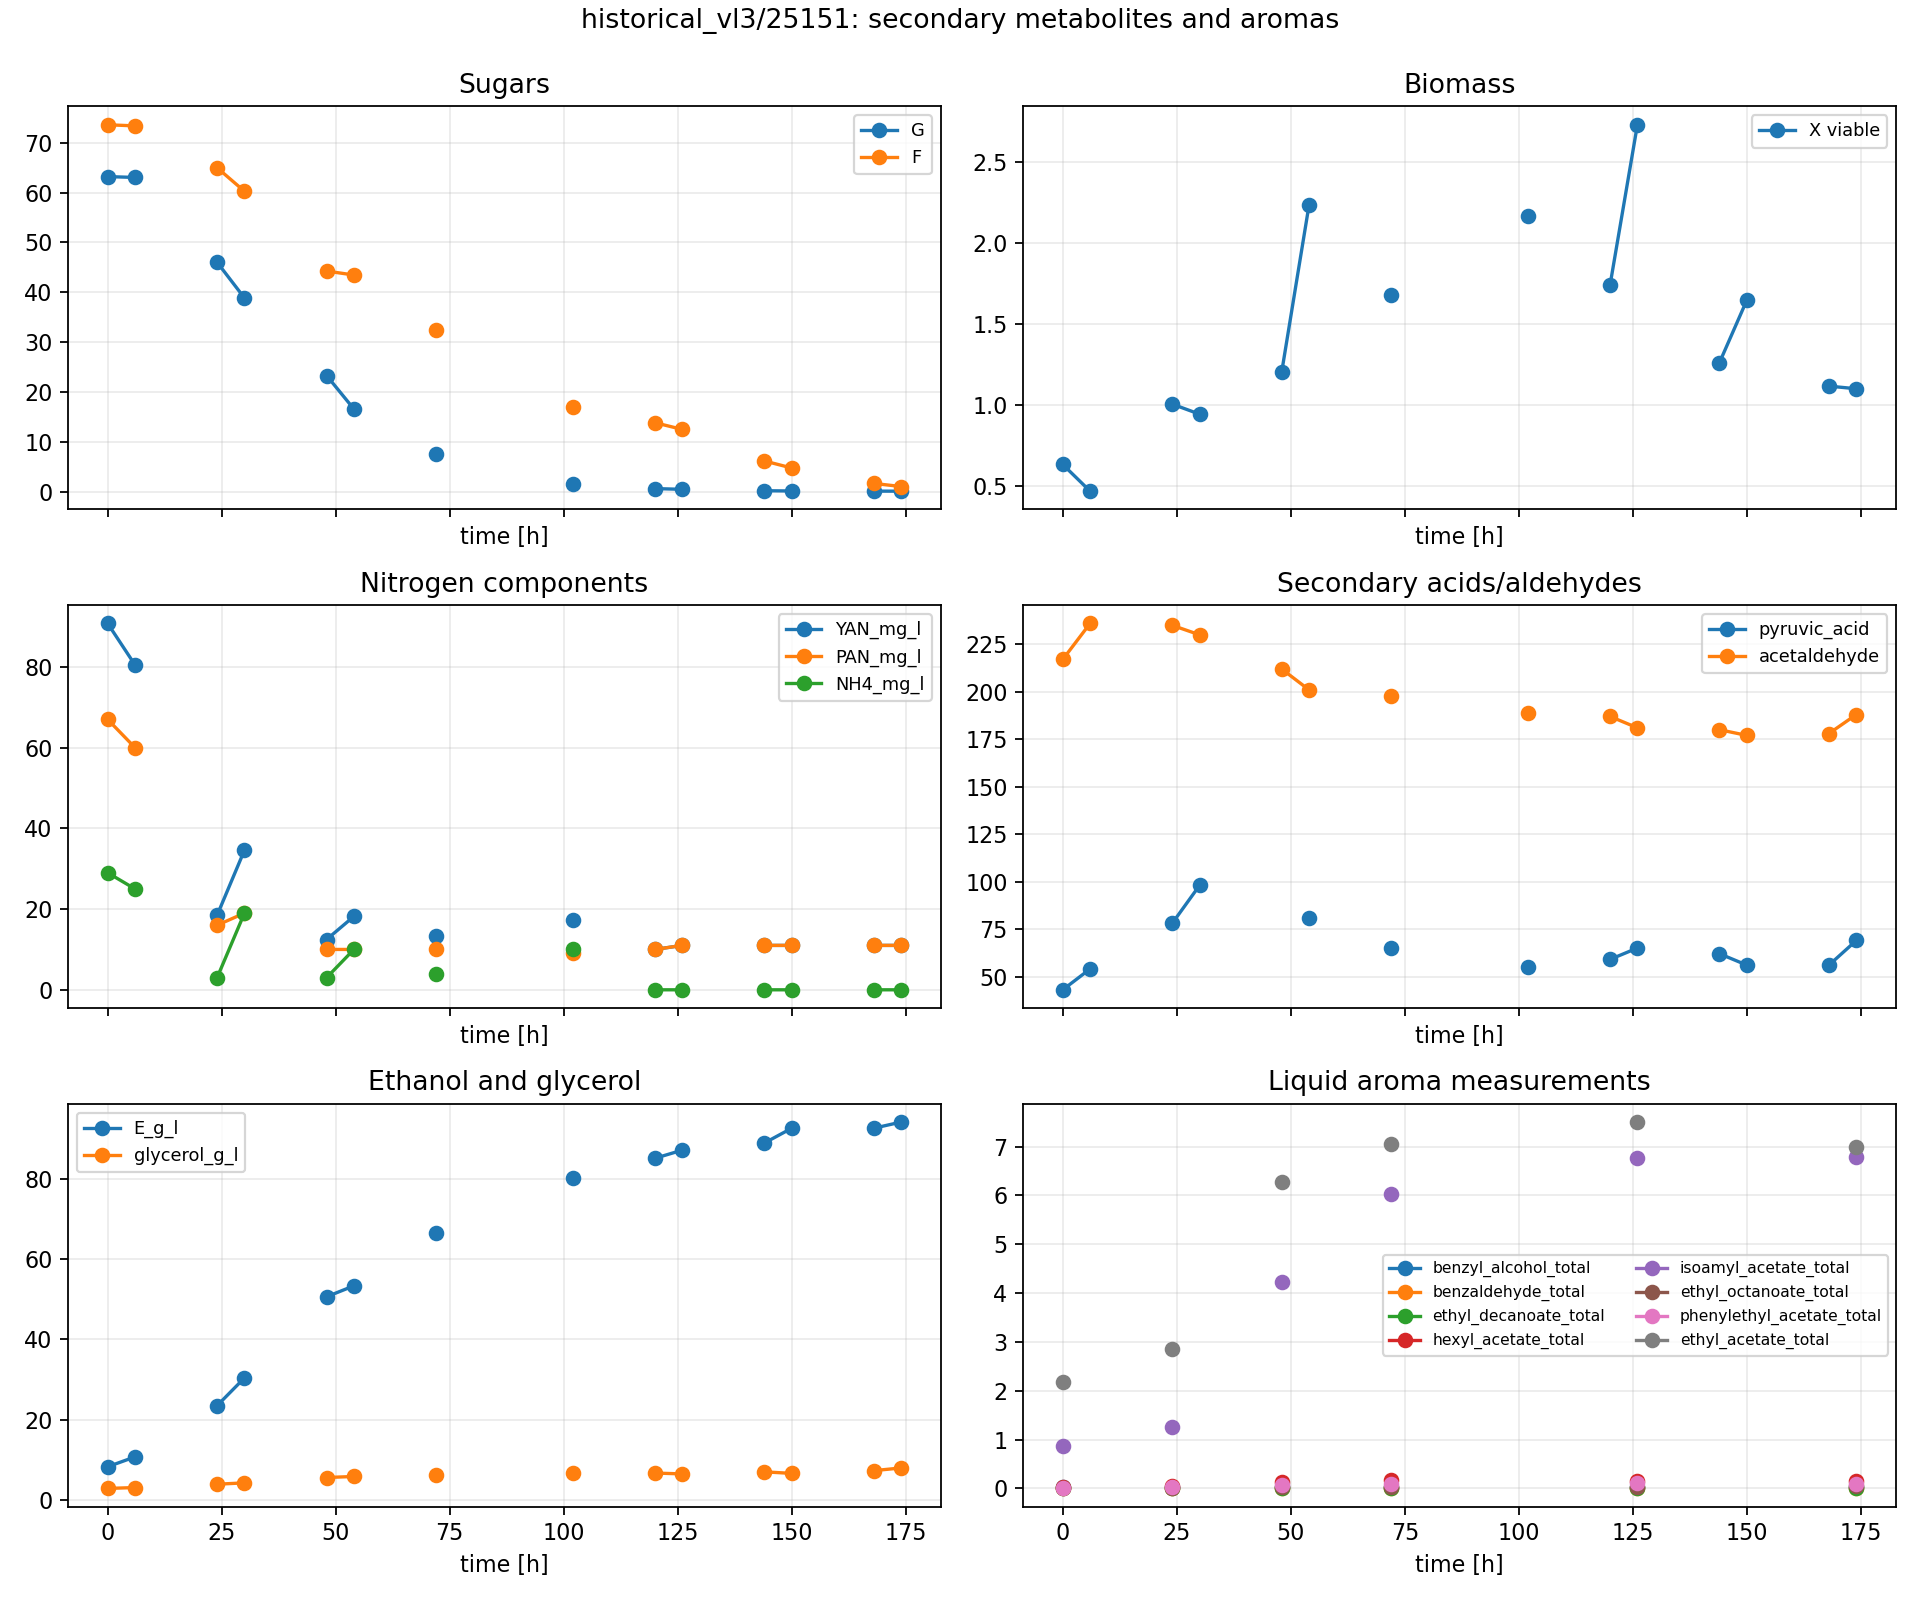

secondary_historical_vl3_25170.png


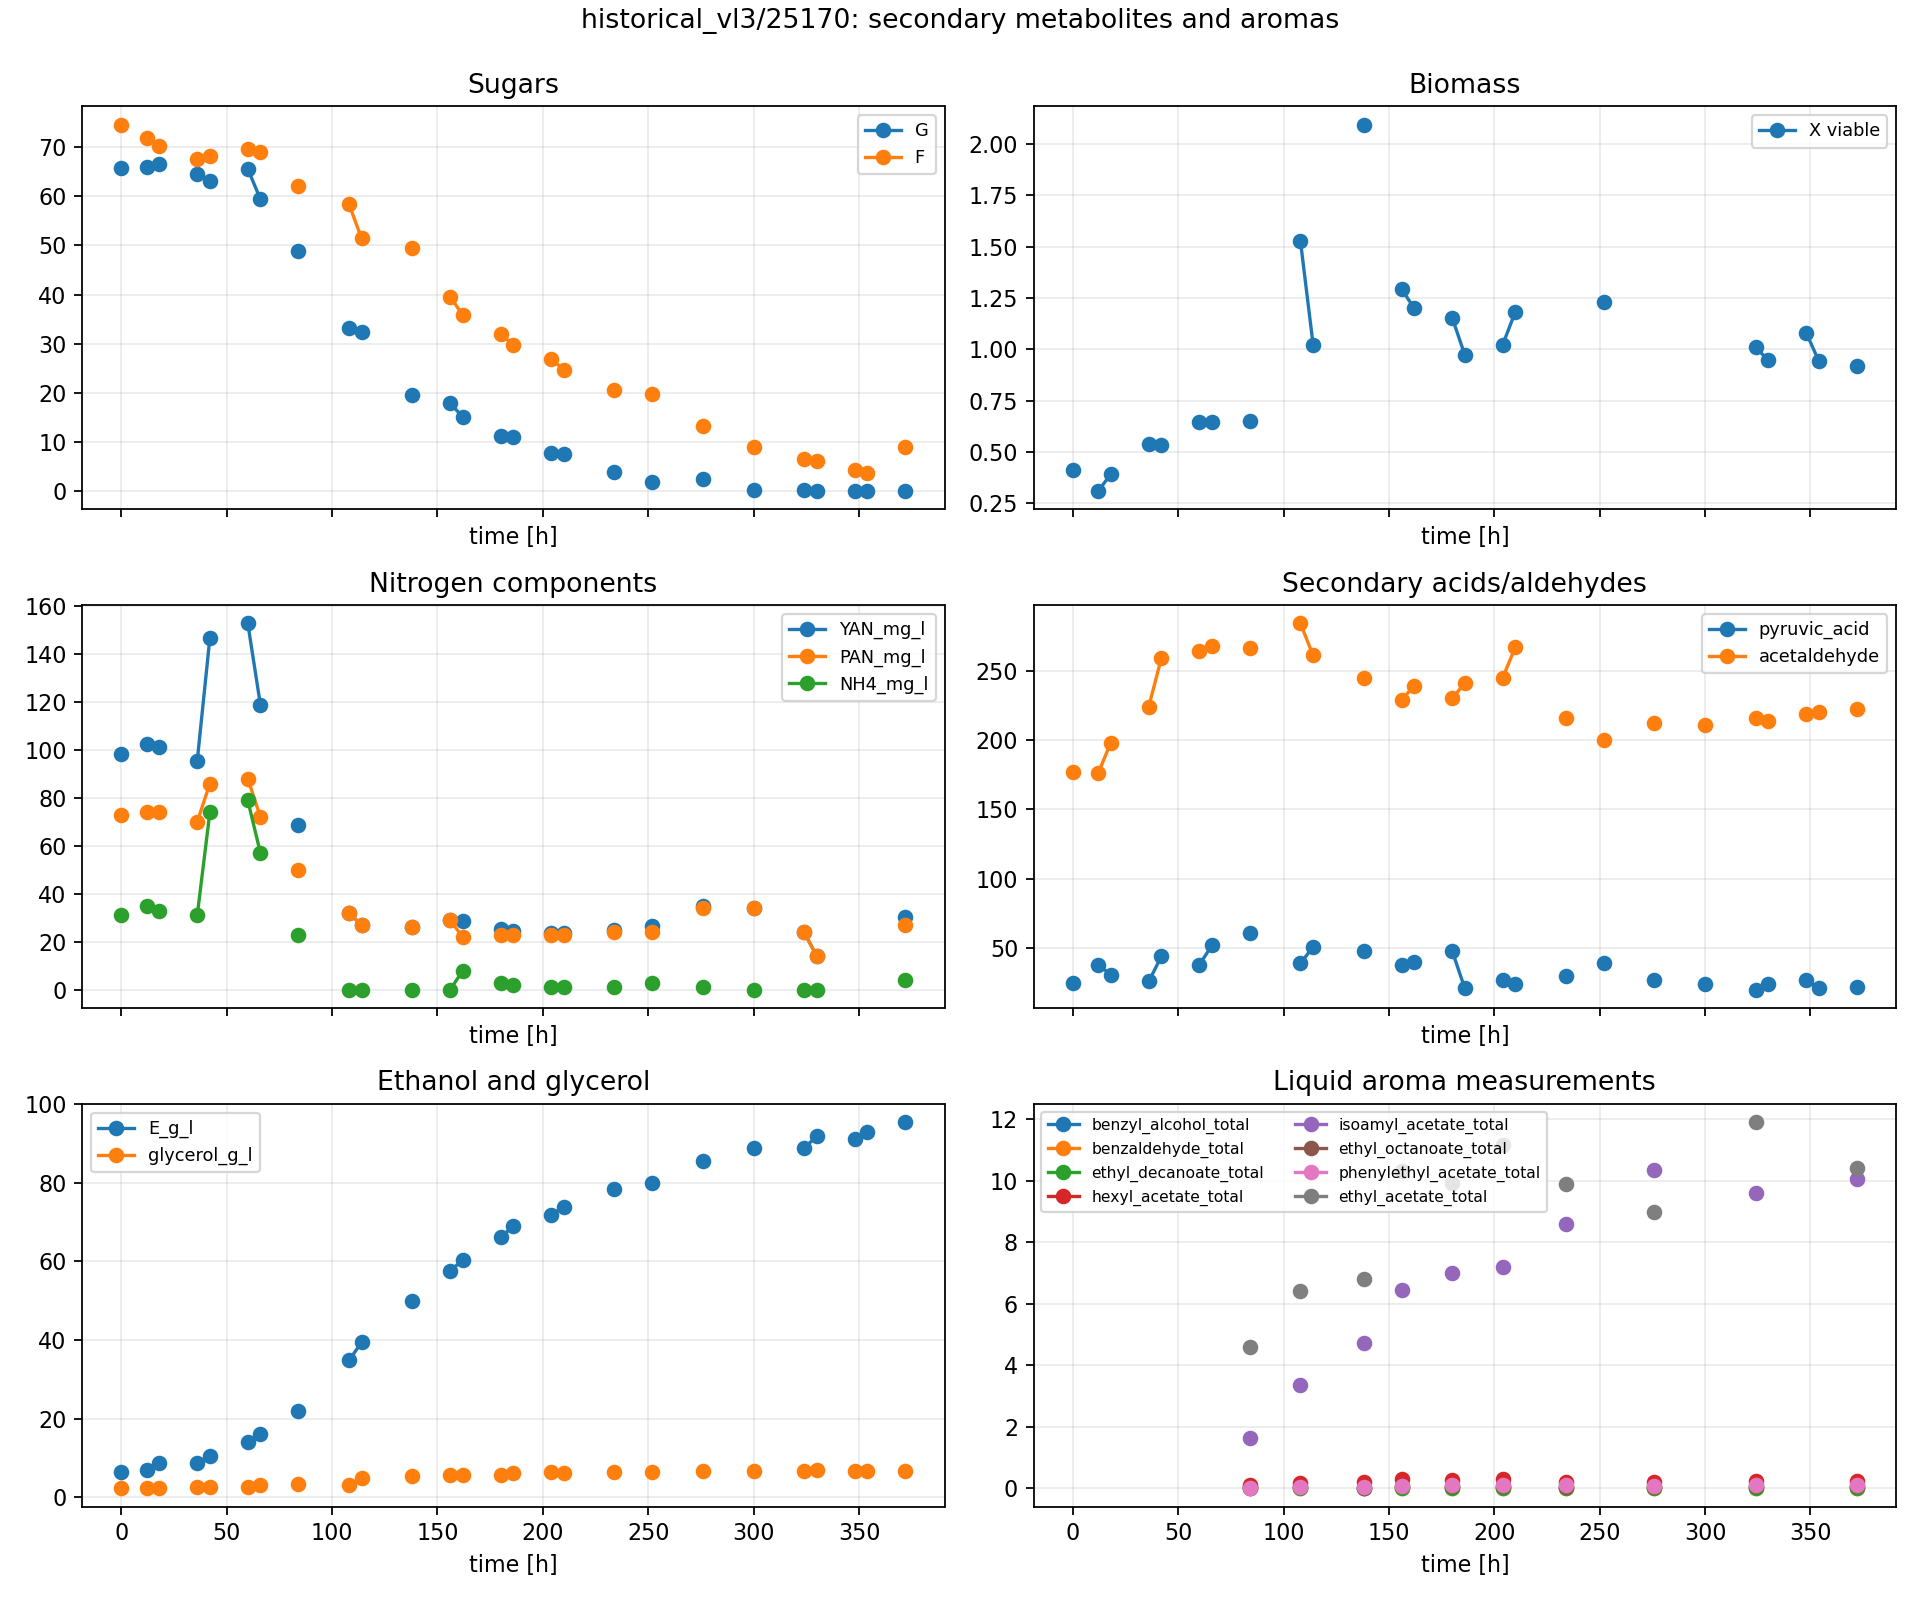

secondary_historical_vl3_25171.png


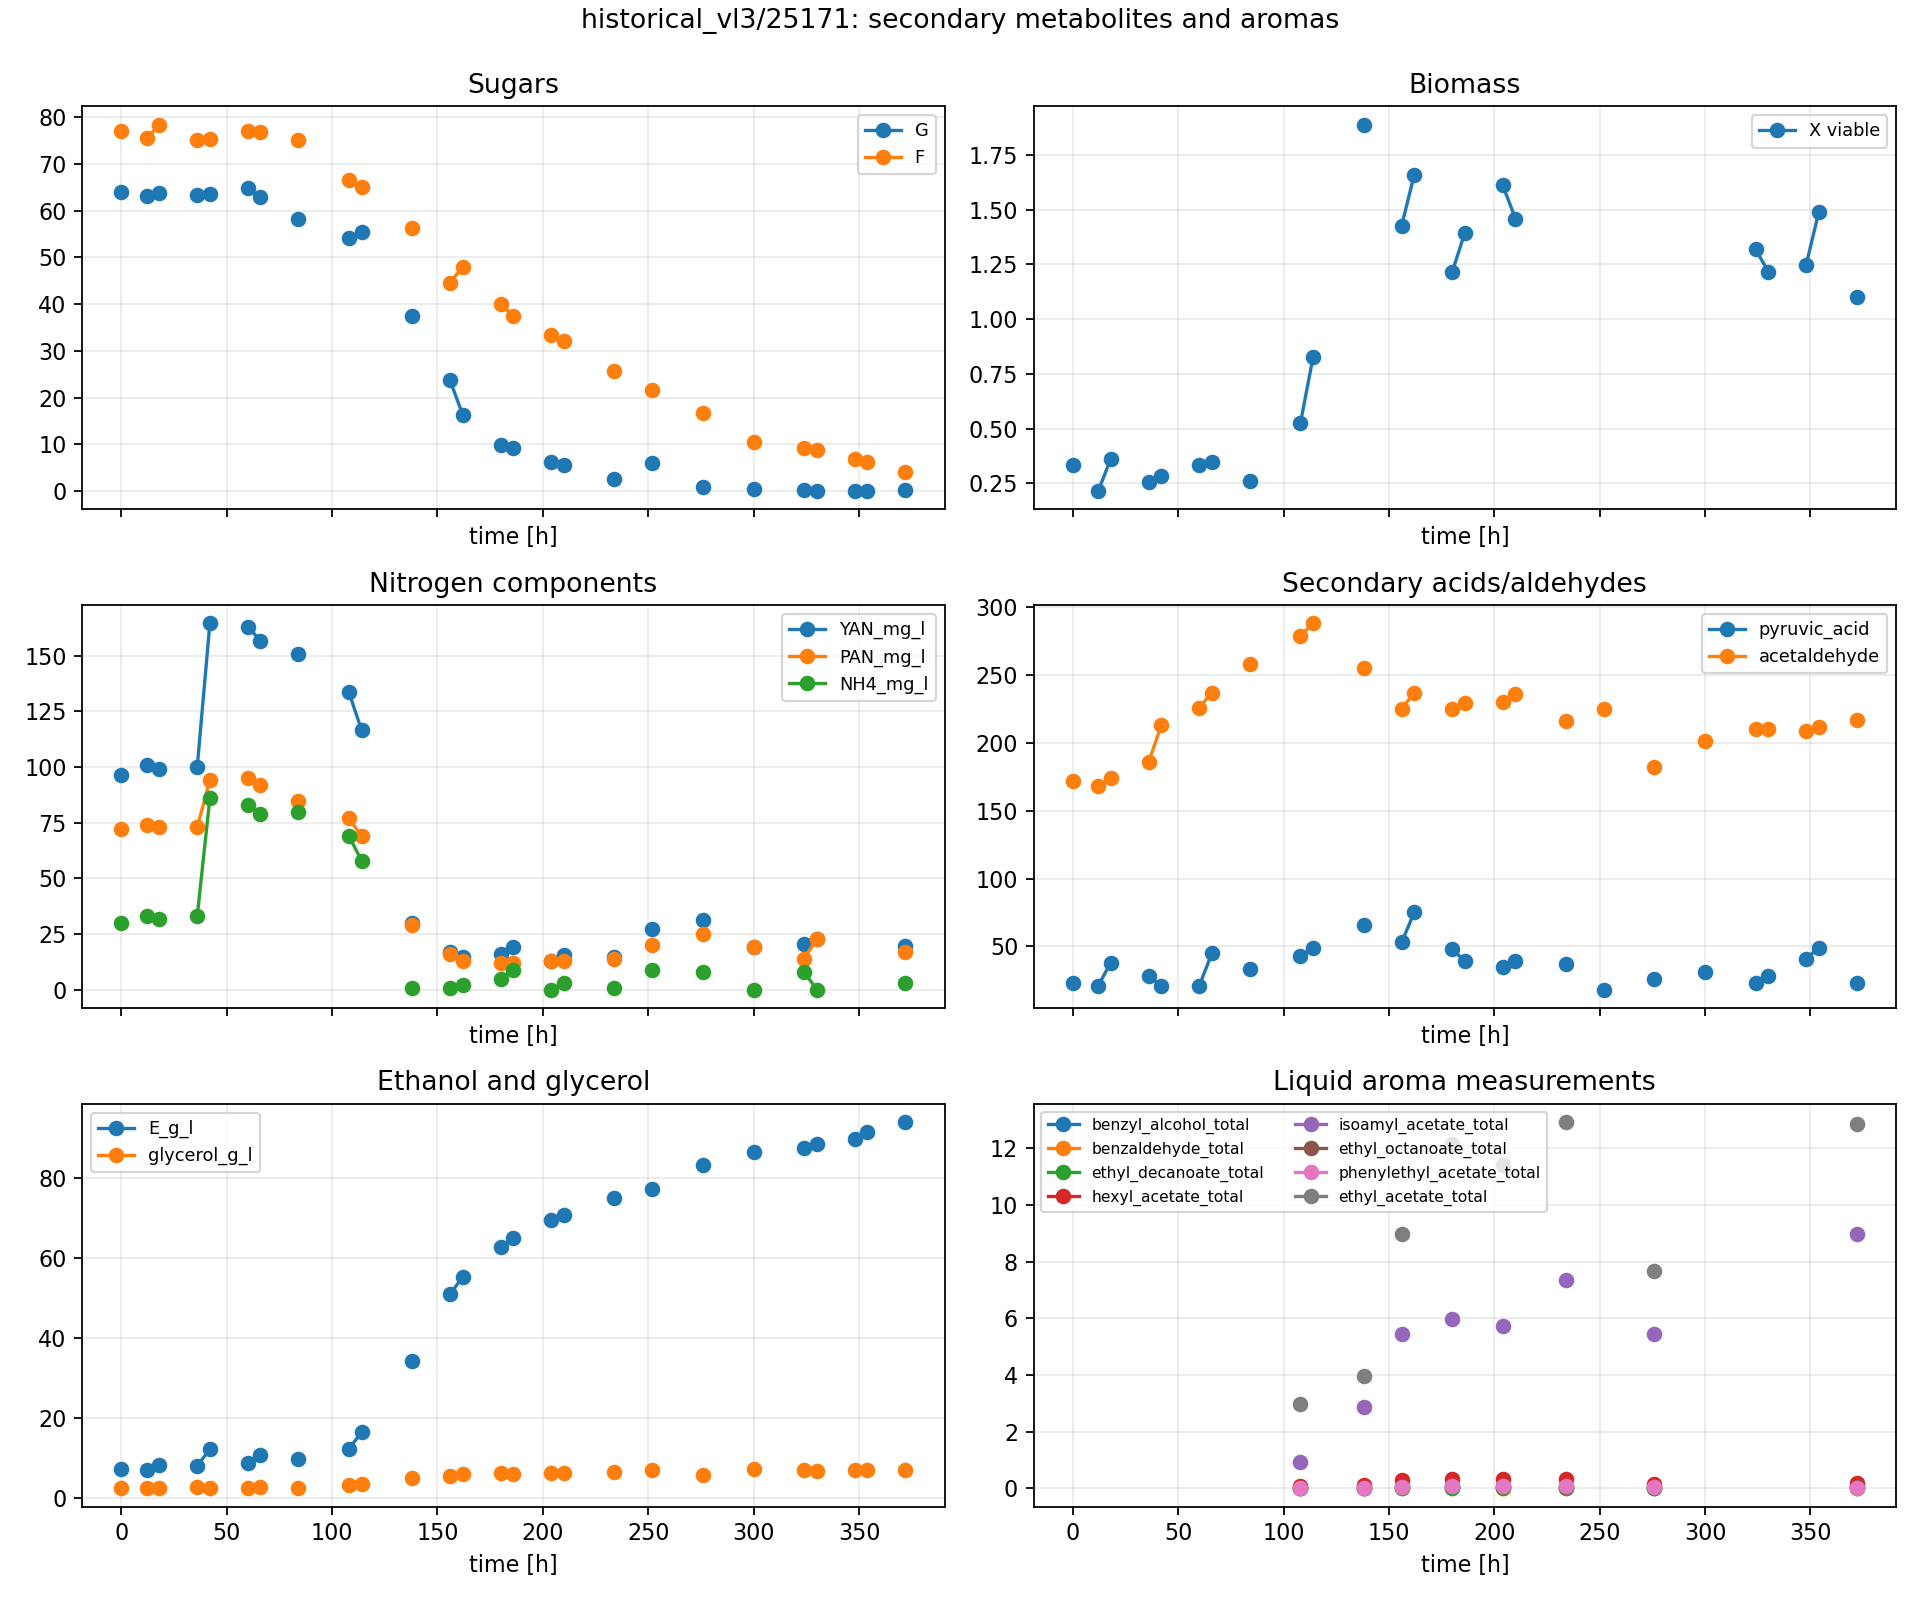

secondary_natural_LAB004.png


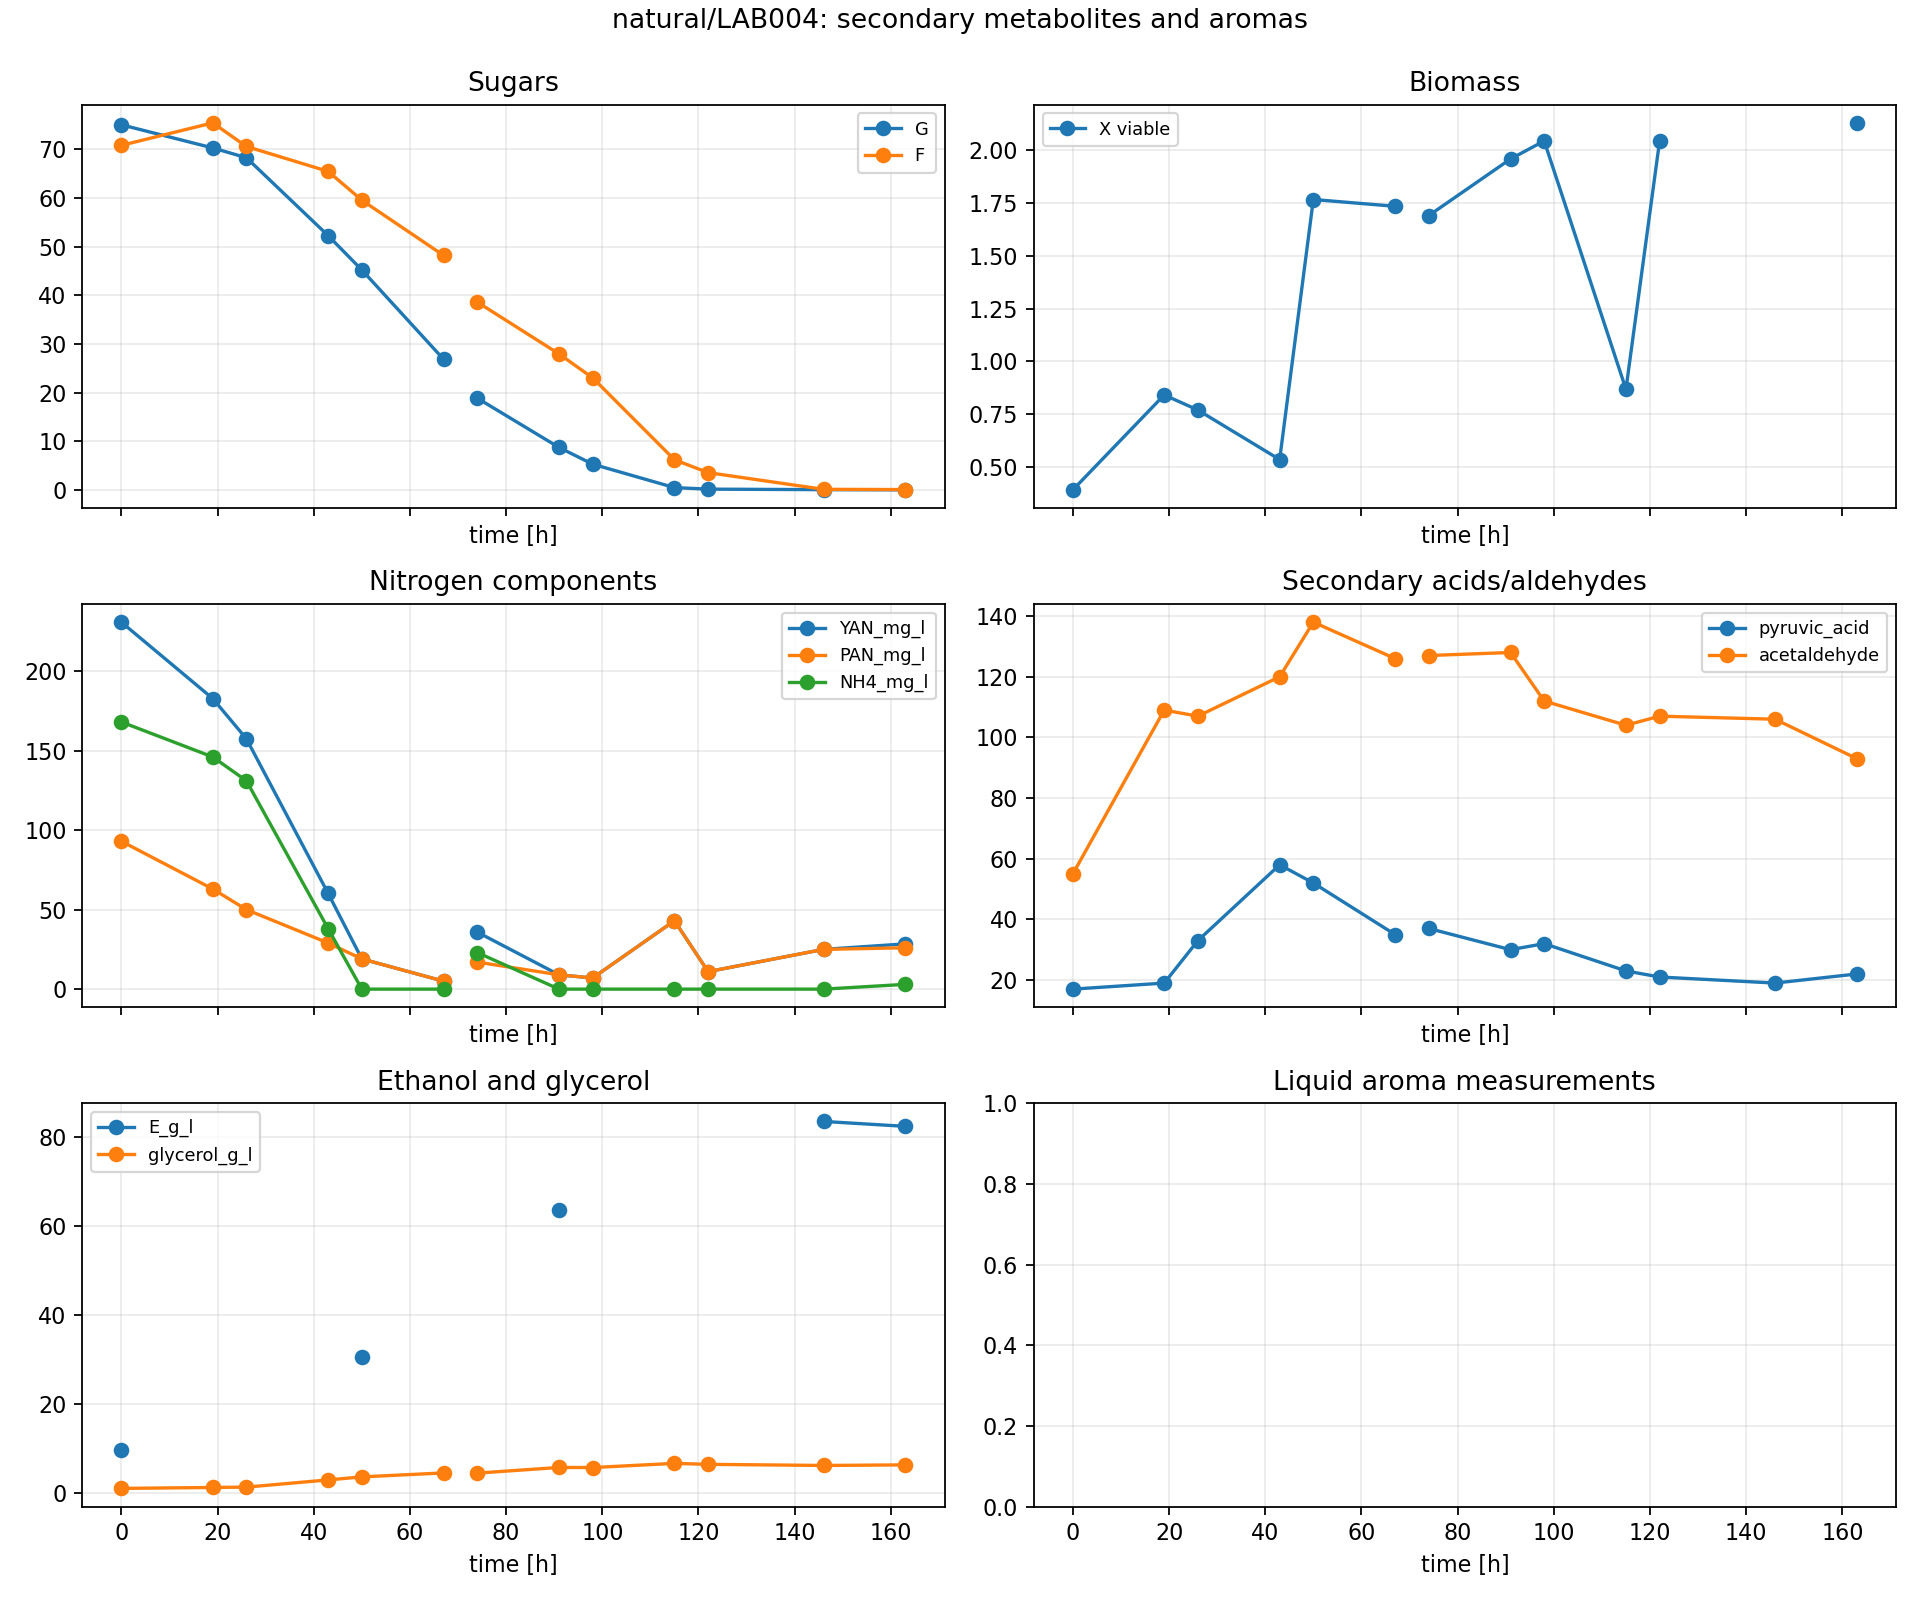

secondary_natural_LAB005.png


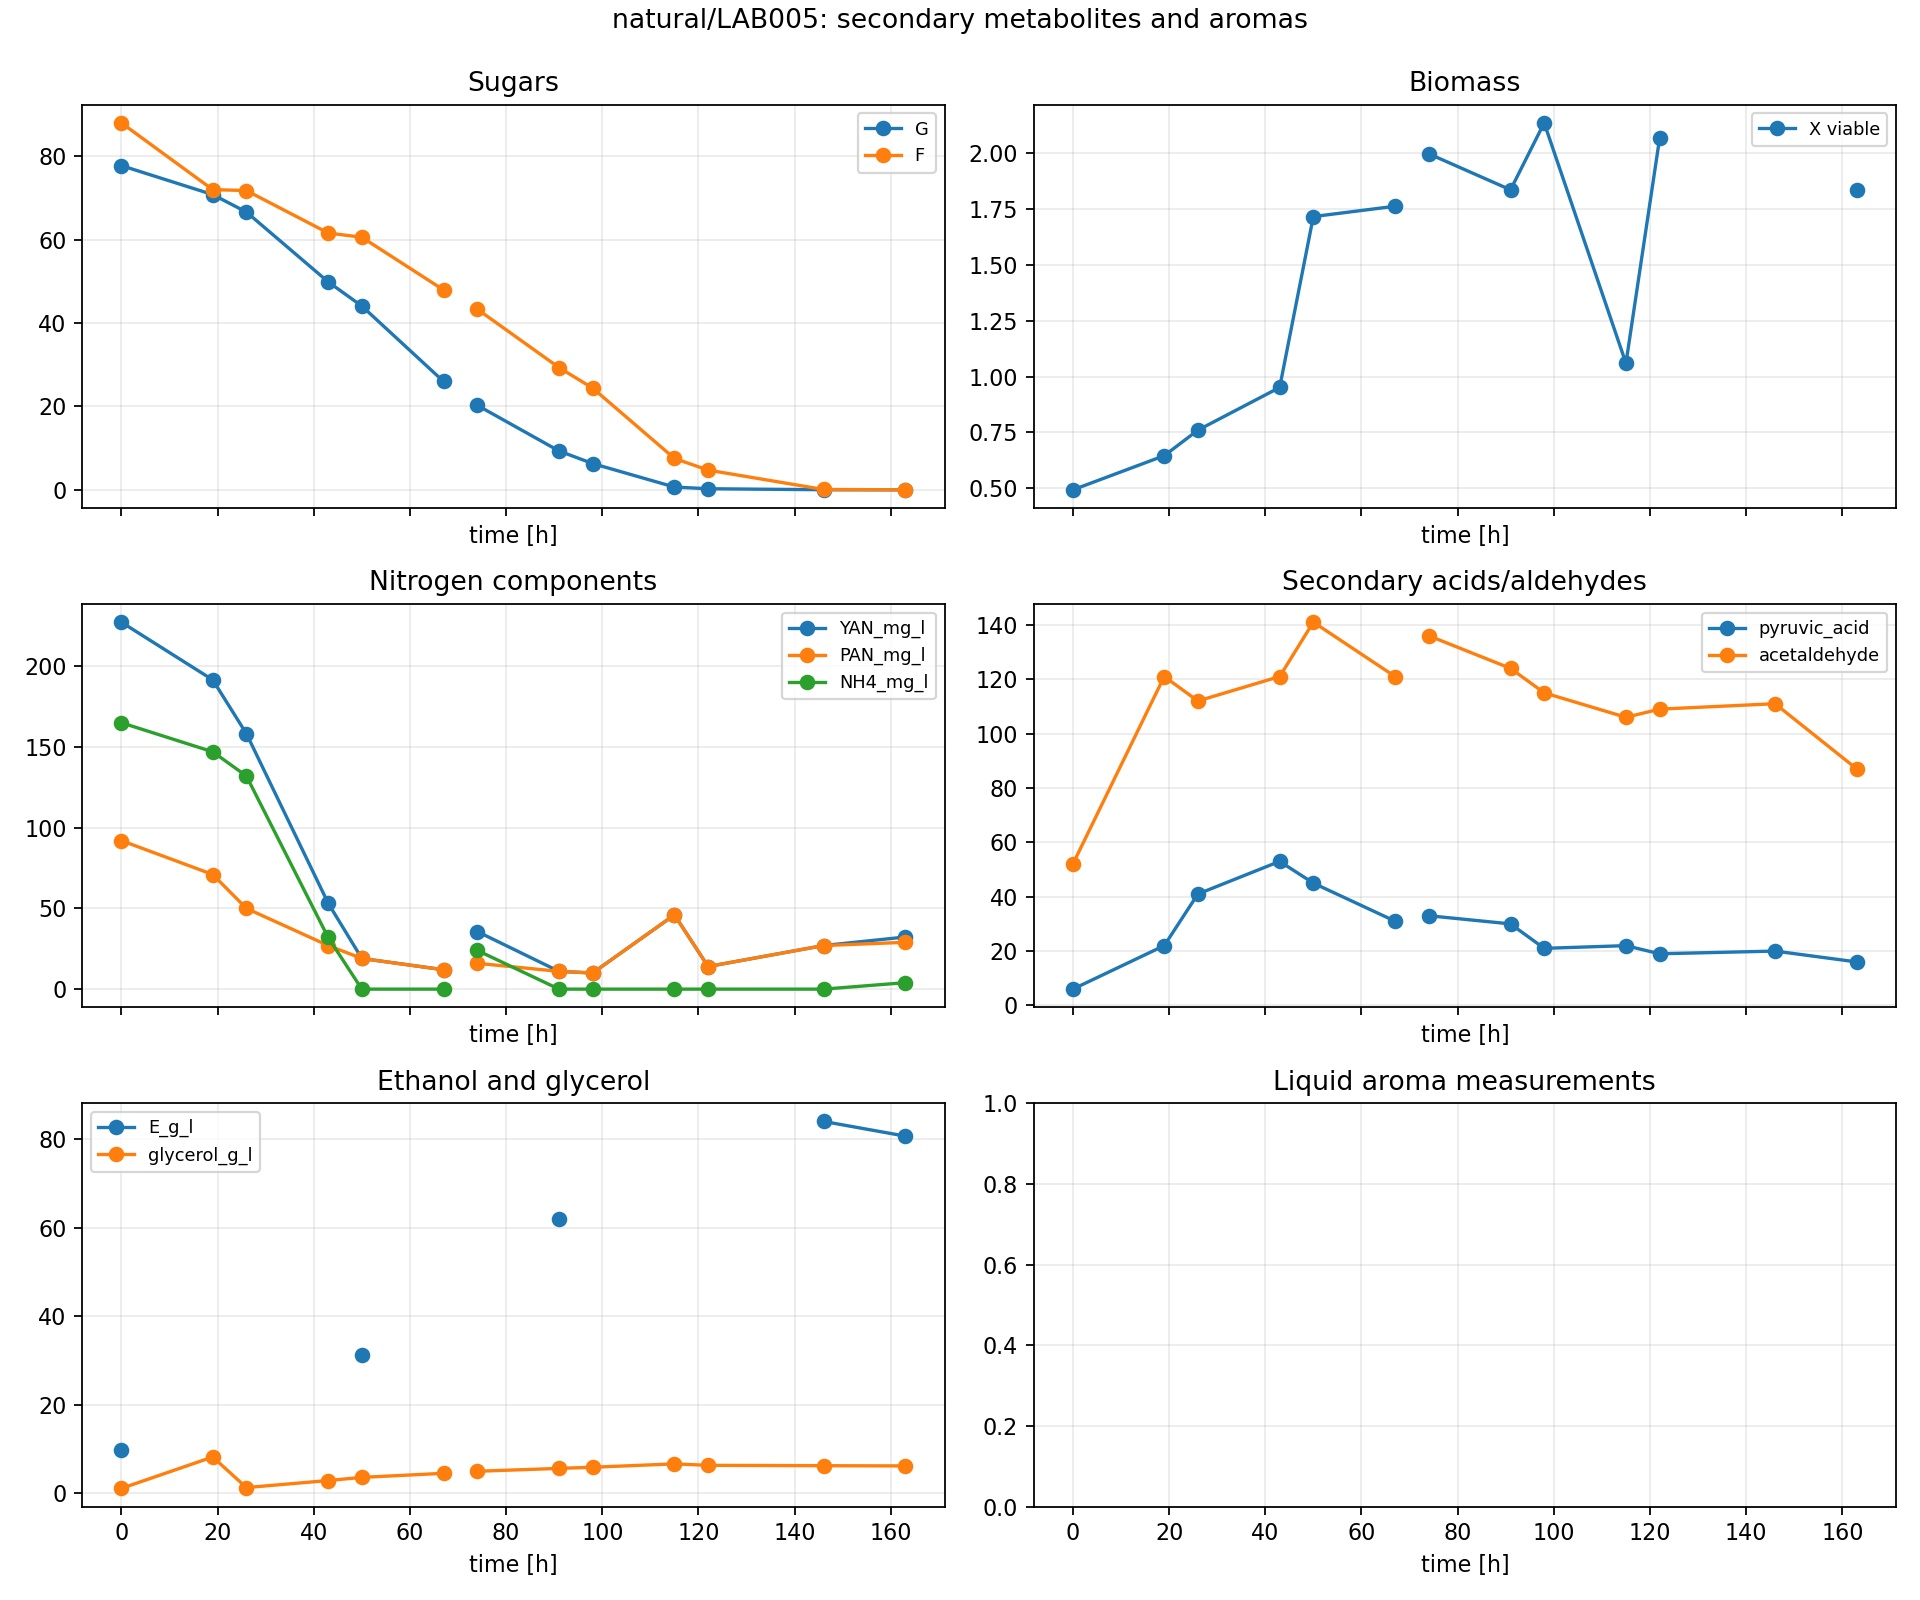

secondary_natural_LAB006.png


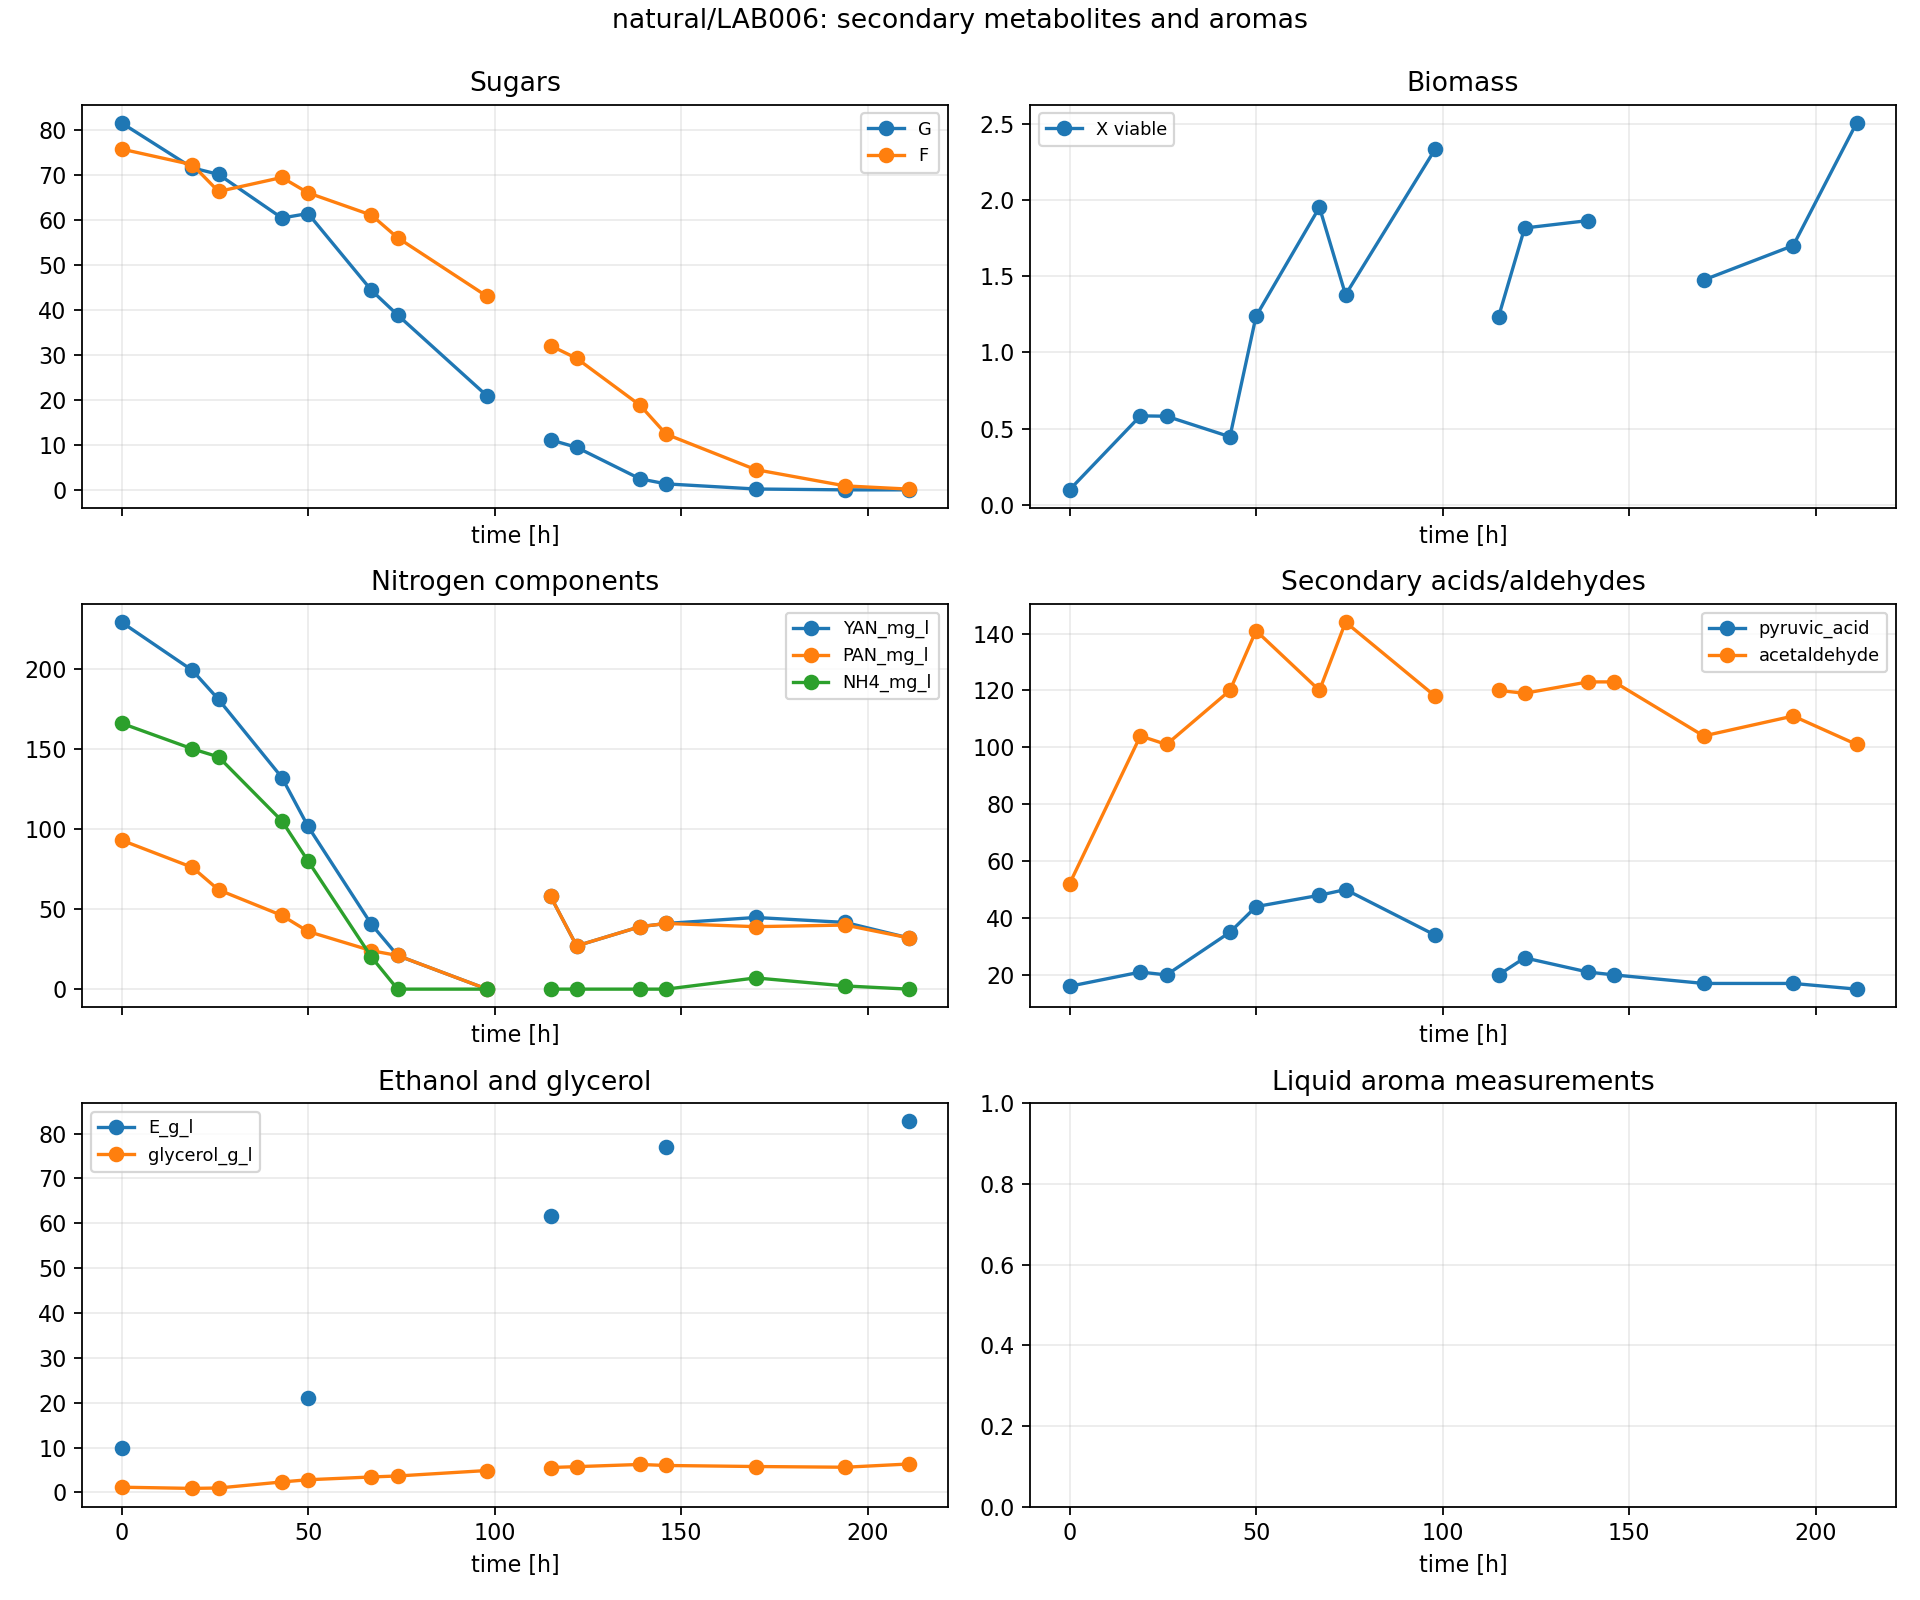

secondary_natural_LAB007.png


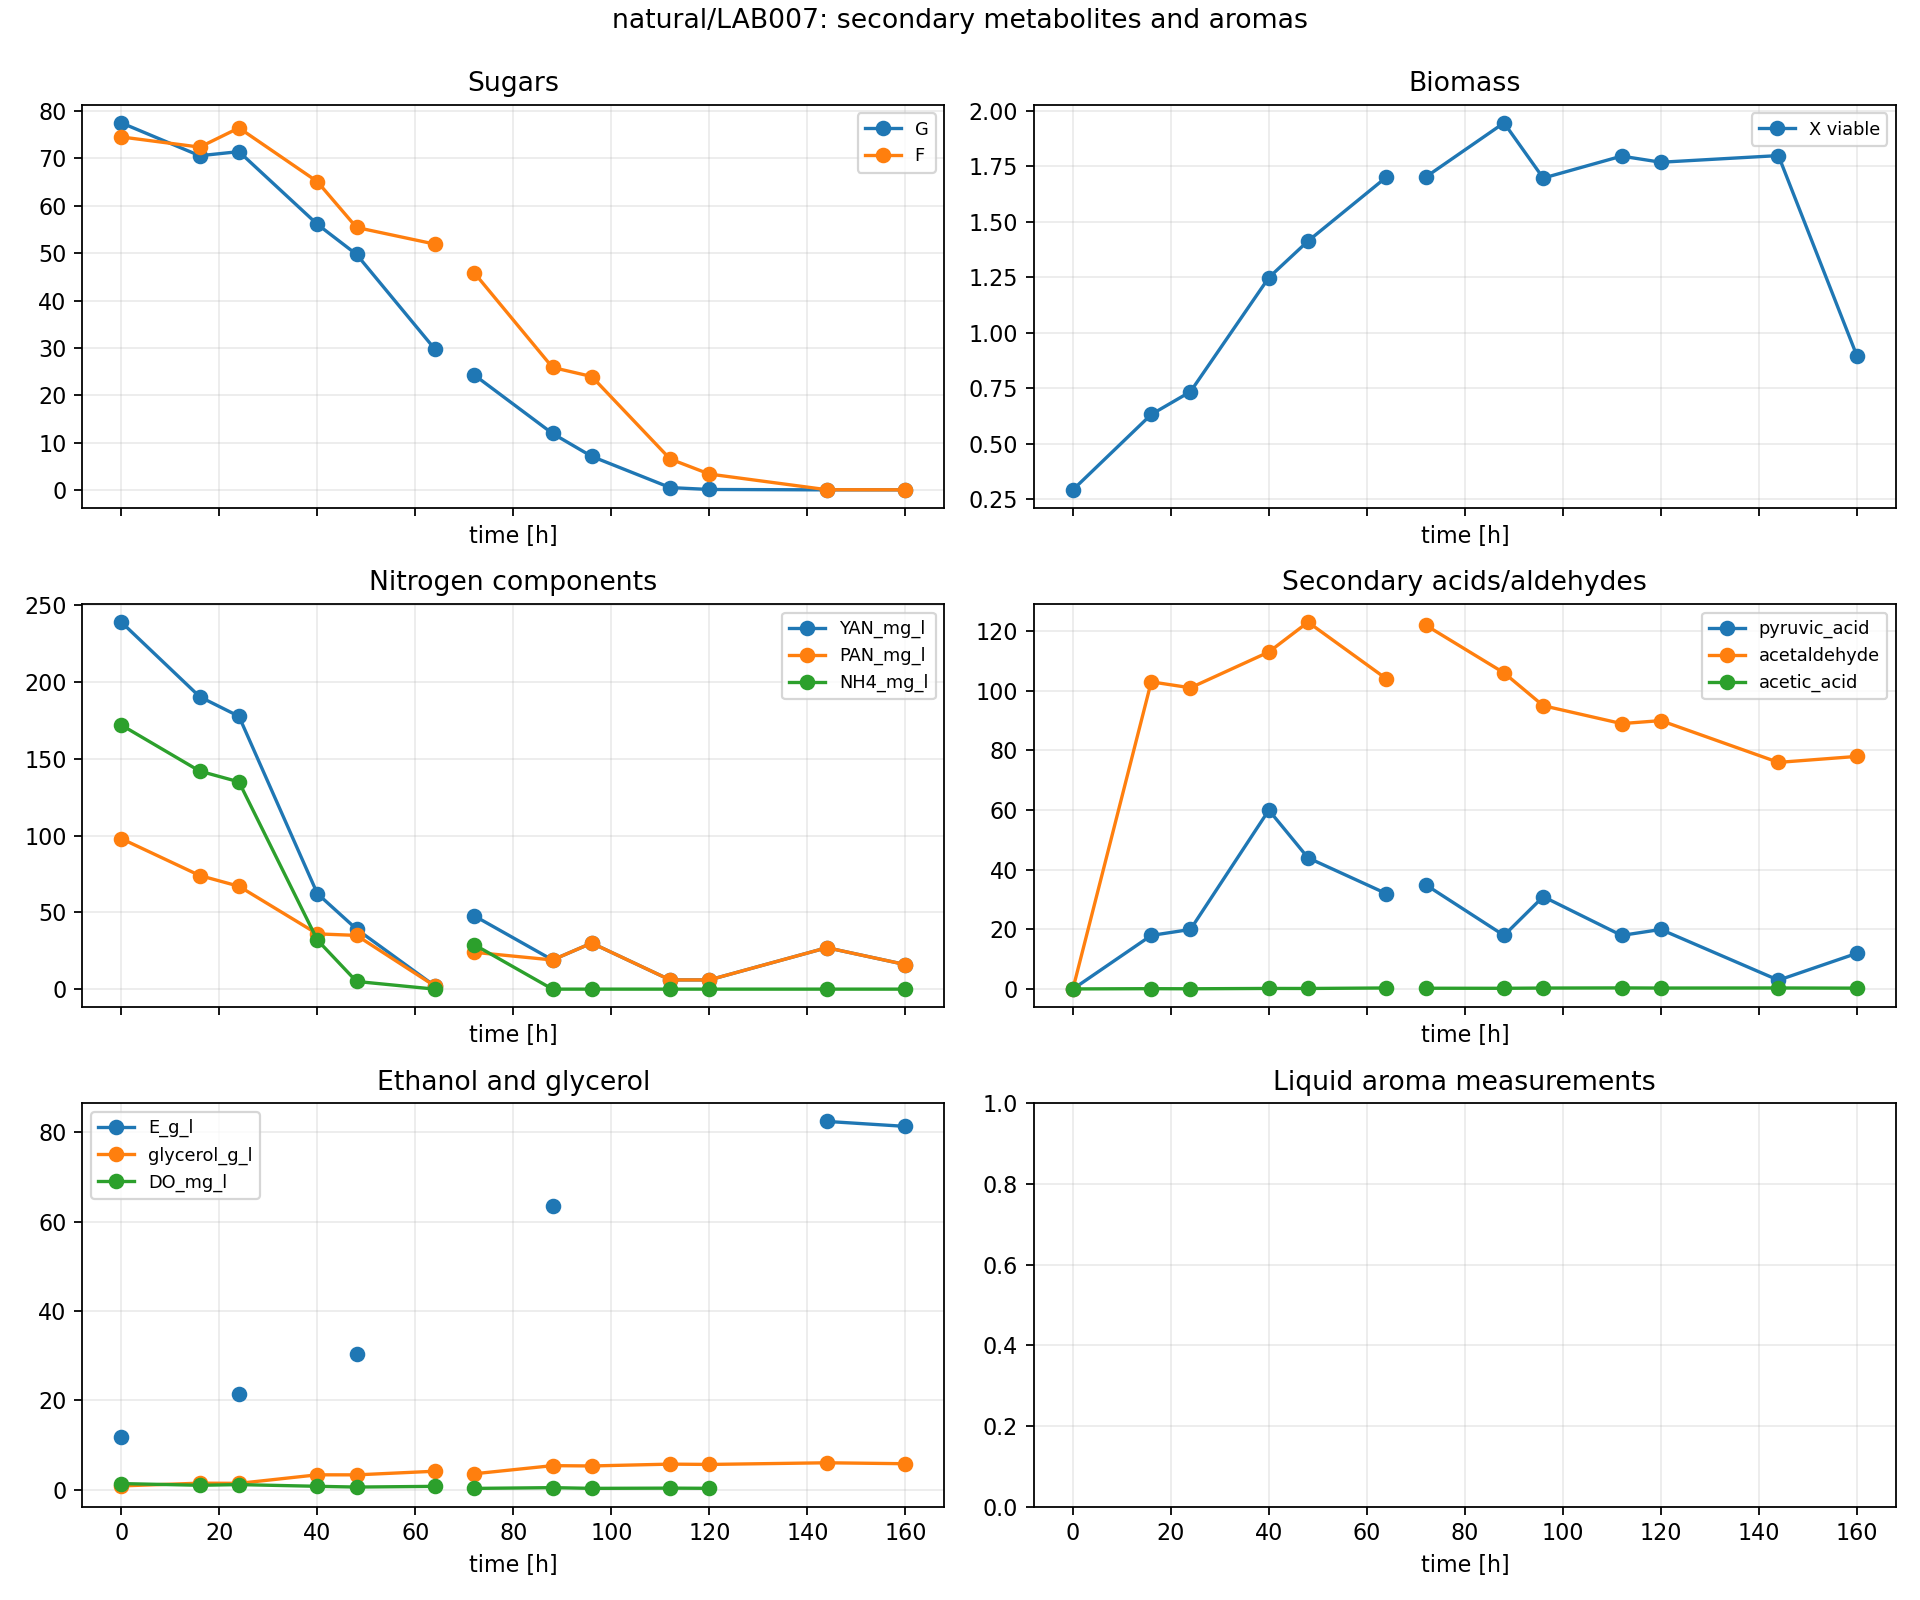

In [4]:
for png in sorted((RESULTS / 'plots').glob('secondary_*.png'))[:12]:
    print(png.name)
    display(Image(filename=str(png)))

## Variable overlays

Overlay plots help identify non-Monod behavior, transient peaks, and medium-specific differences.

overlay_acetaldehyde.png


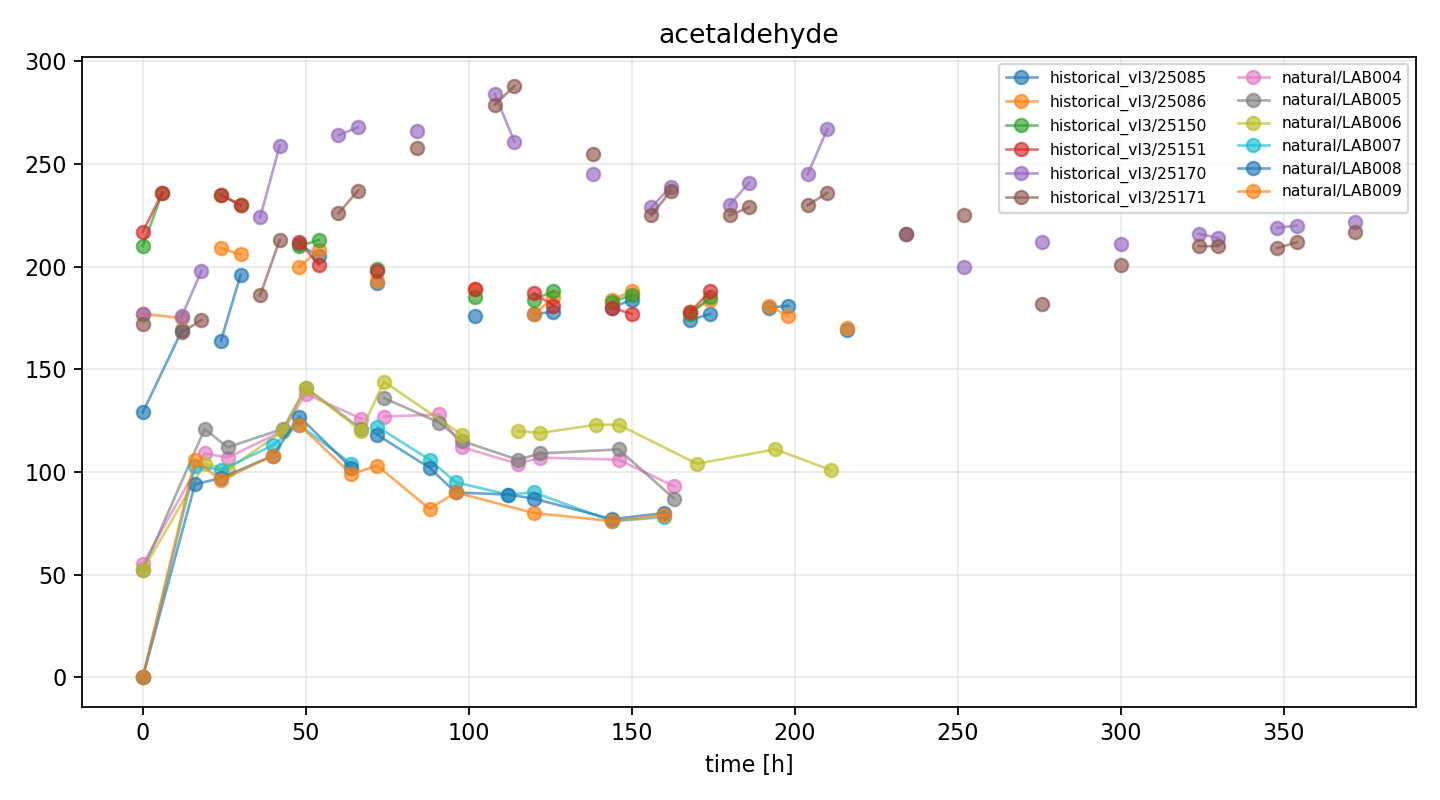

overlay_acetic_acid.png


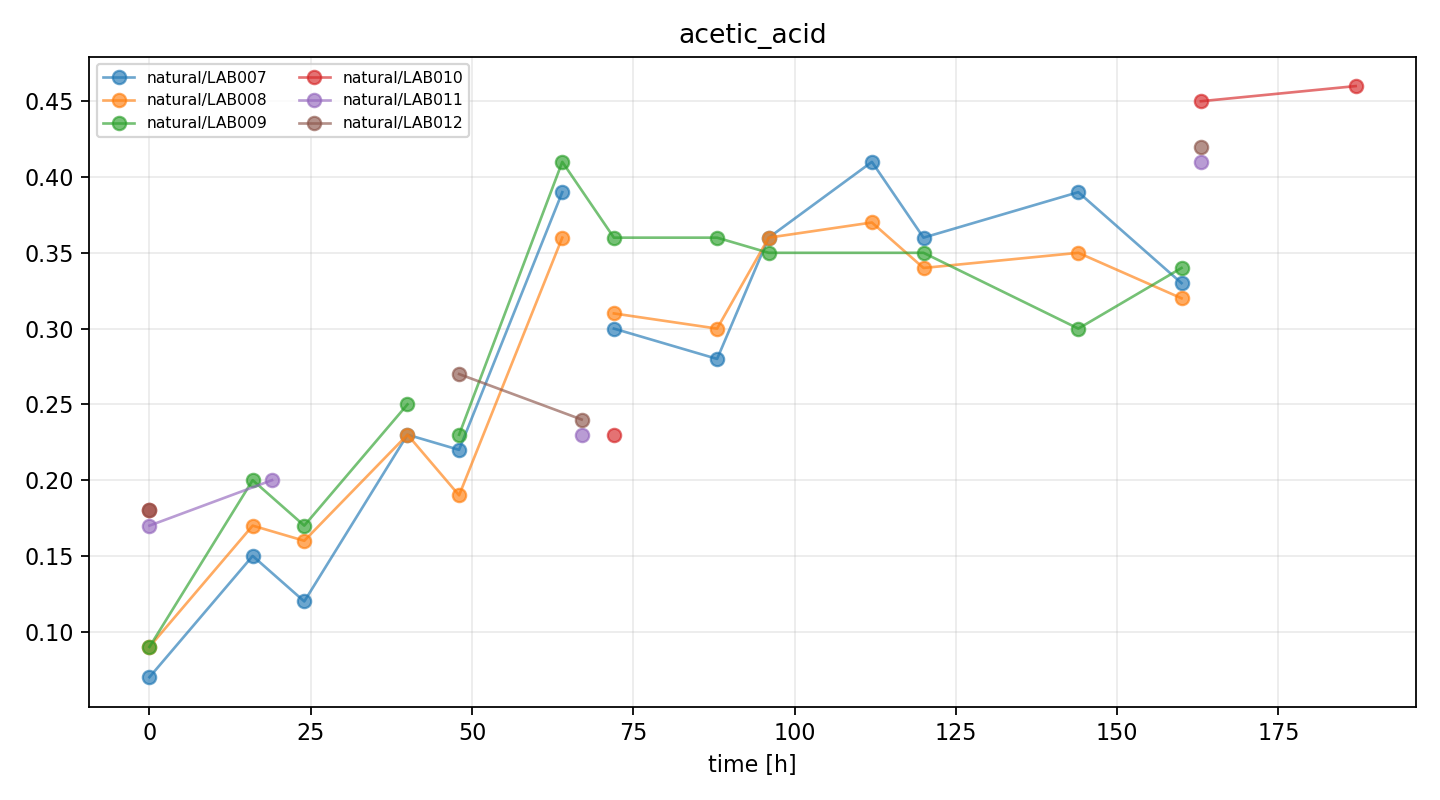

overlay_benzaldehyde_total.png


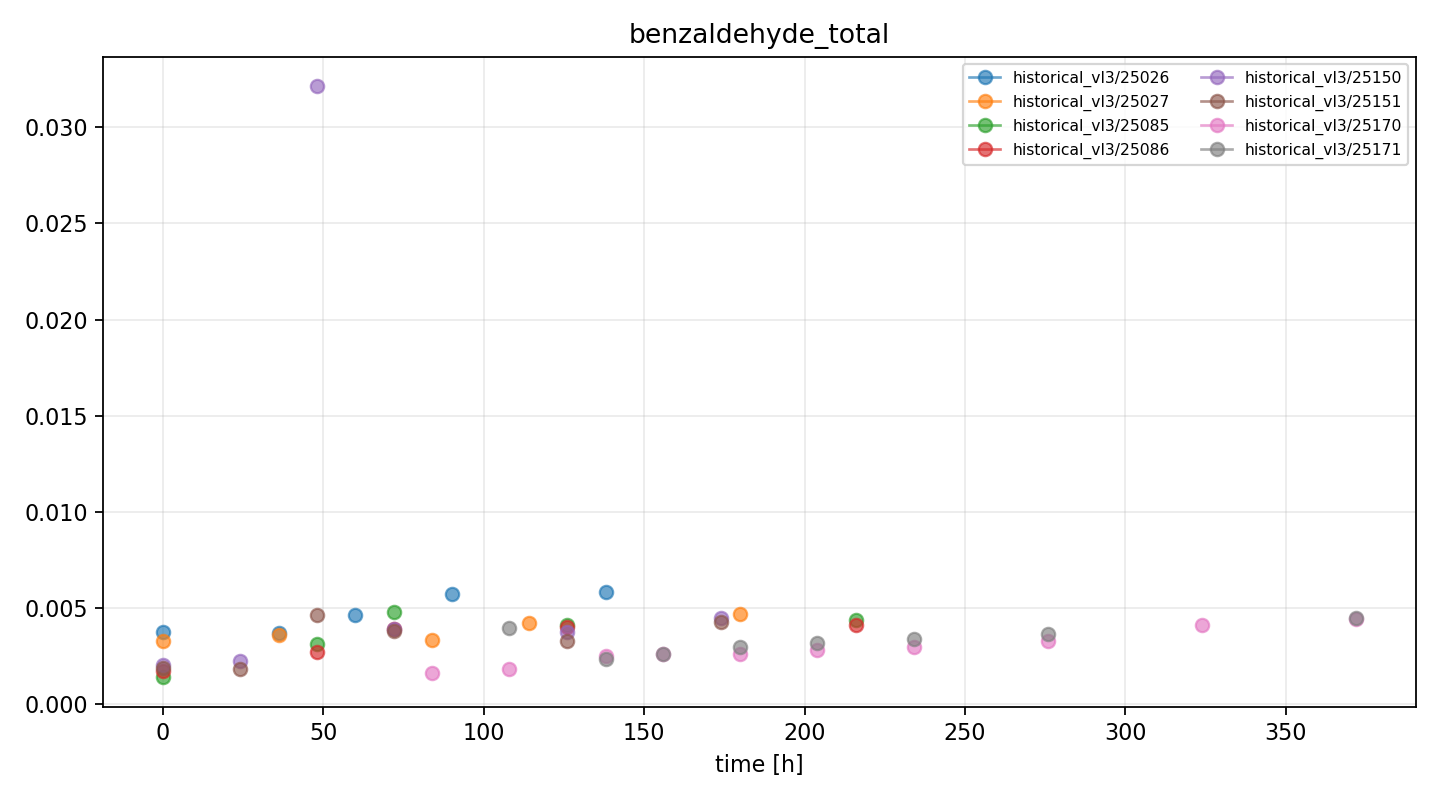

overlay_benzyl_alcohol_total.png


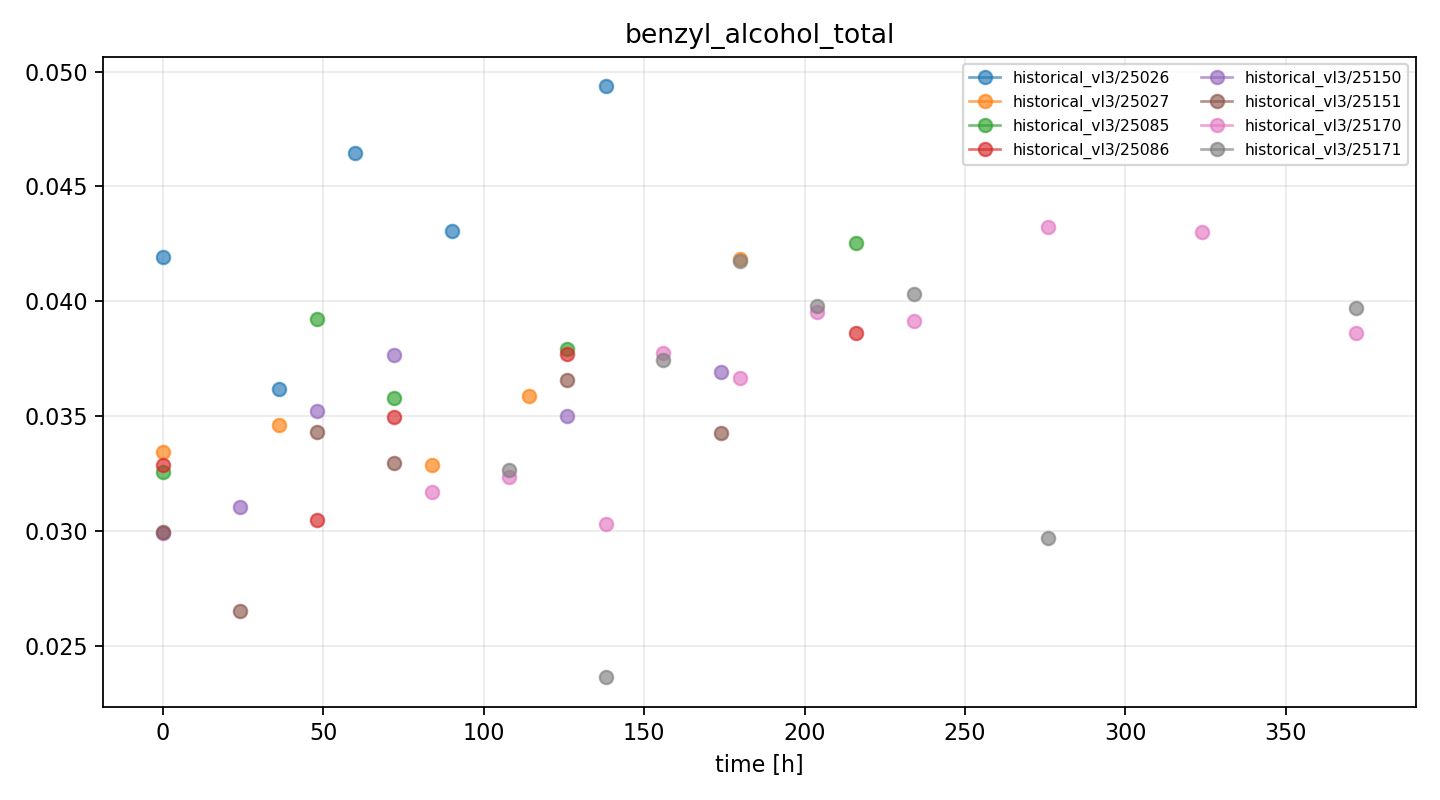

overlay_DO_mg_l.png


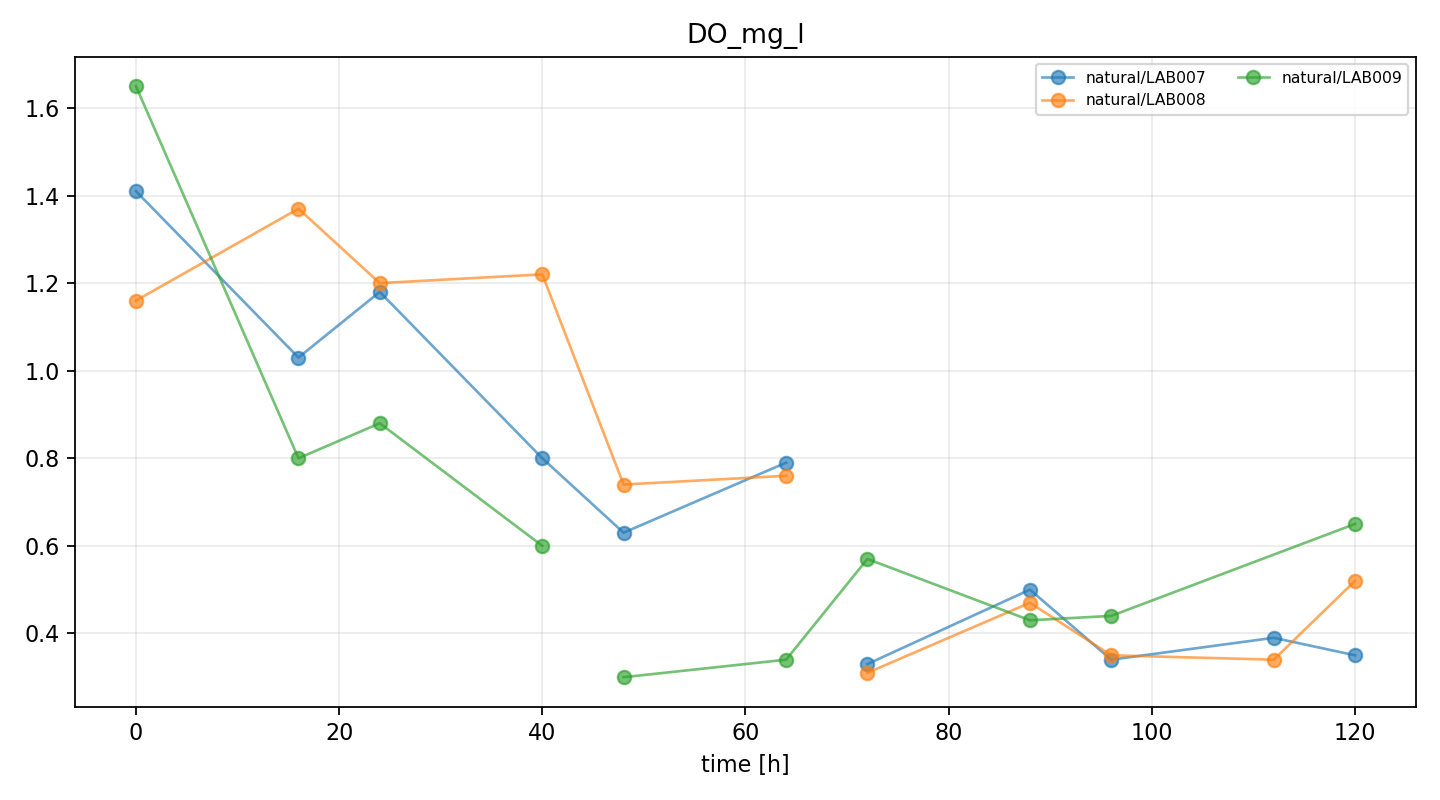

overlay_ethyl_acetate_total.png


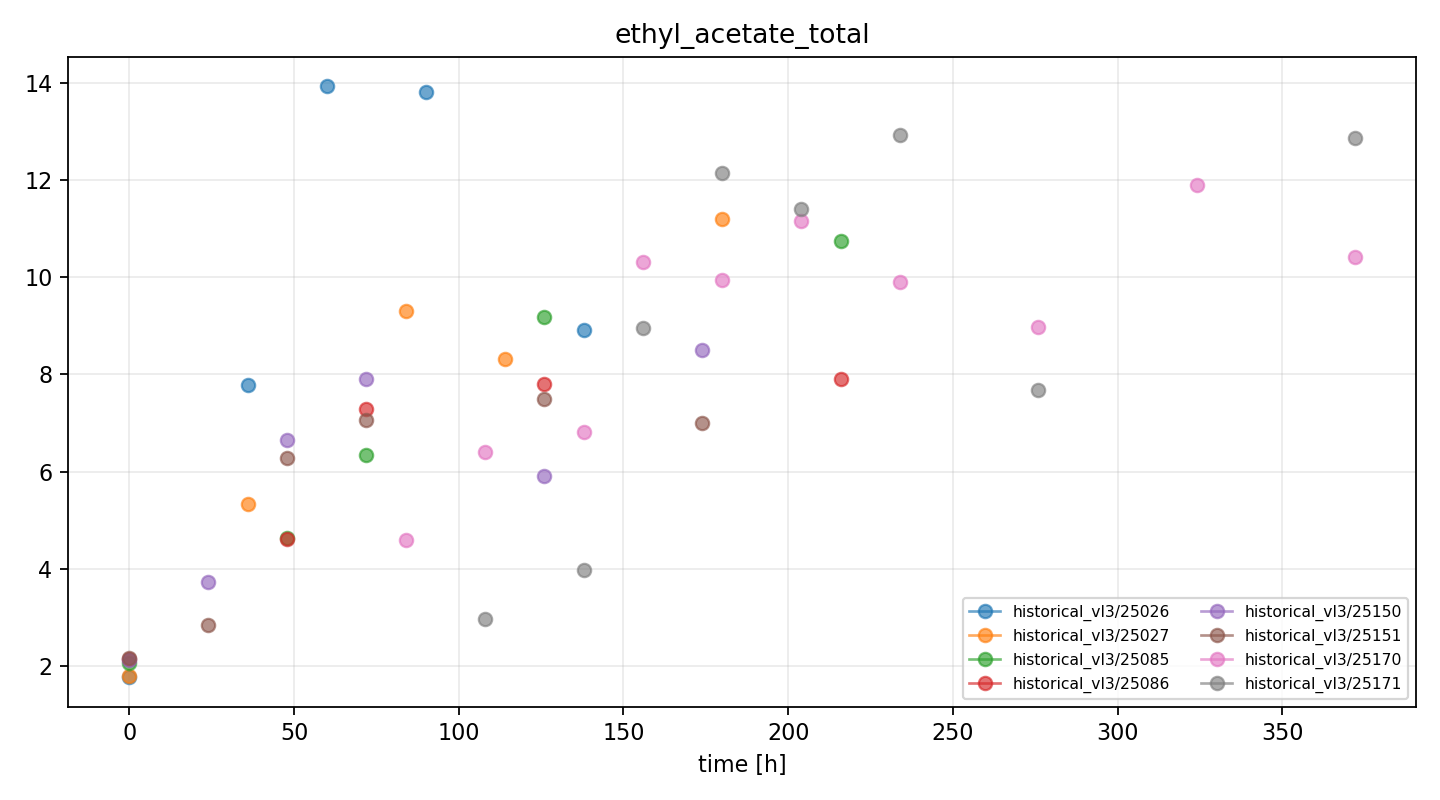

overlay_ethyl_decanoate_total.png


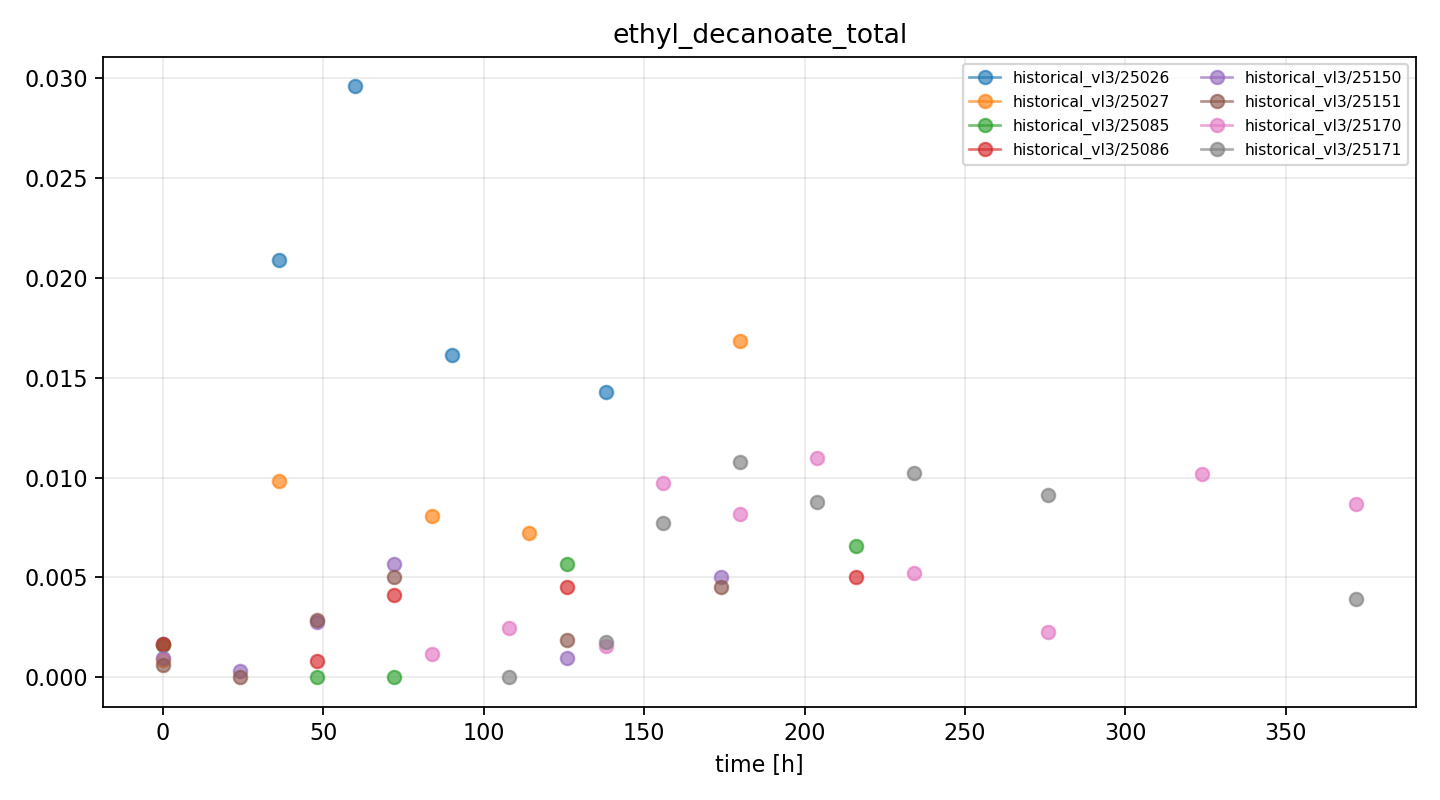

overlay_ethyl_octanoate_total.png


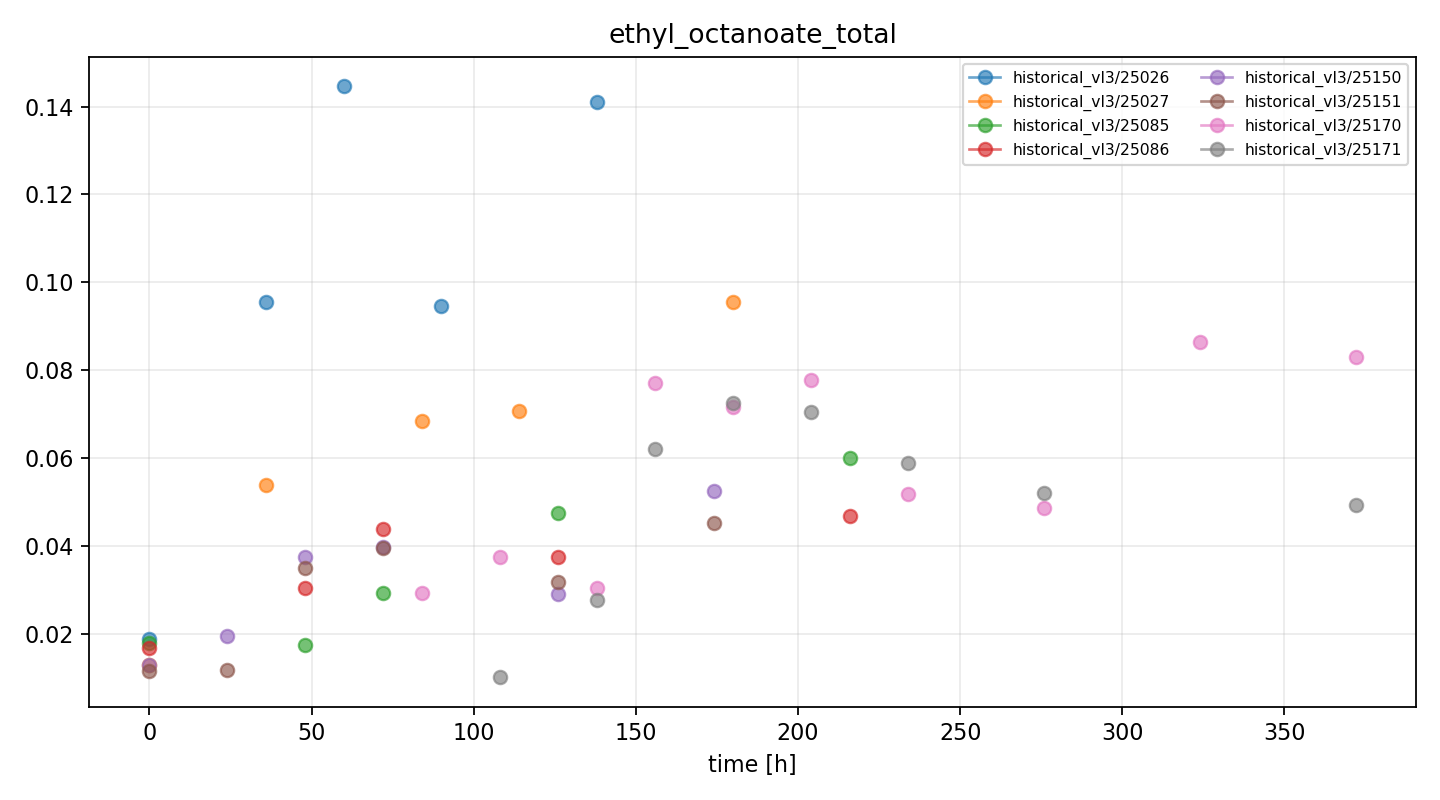

overlay_hexyl_acetate_total.png


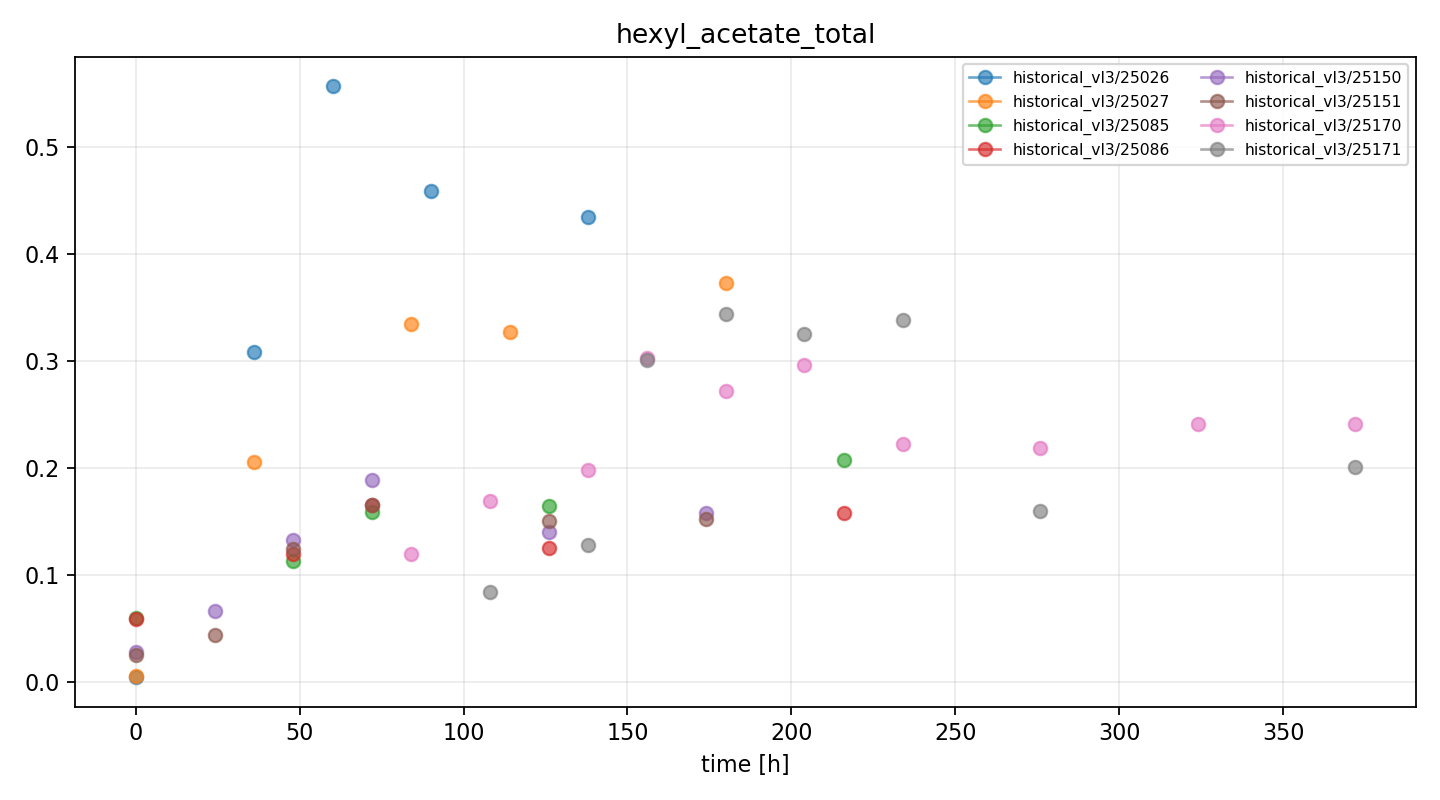

overlay_isoamyl_acetate_total.png


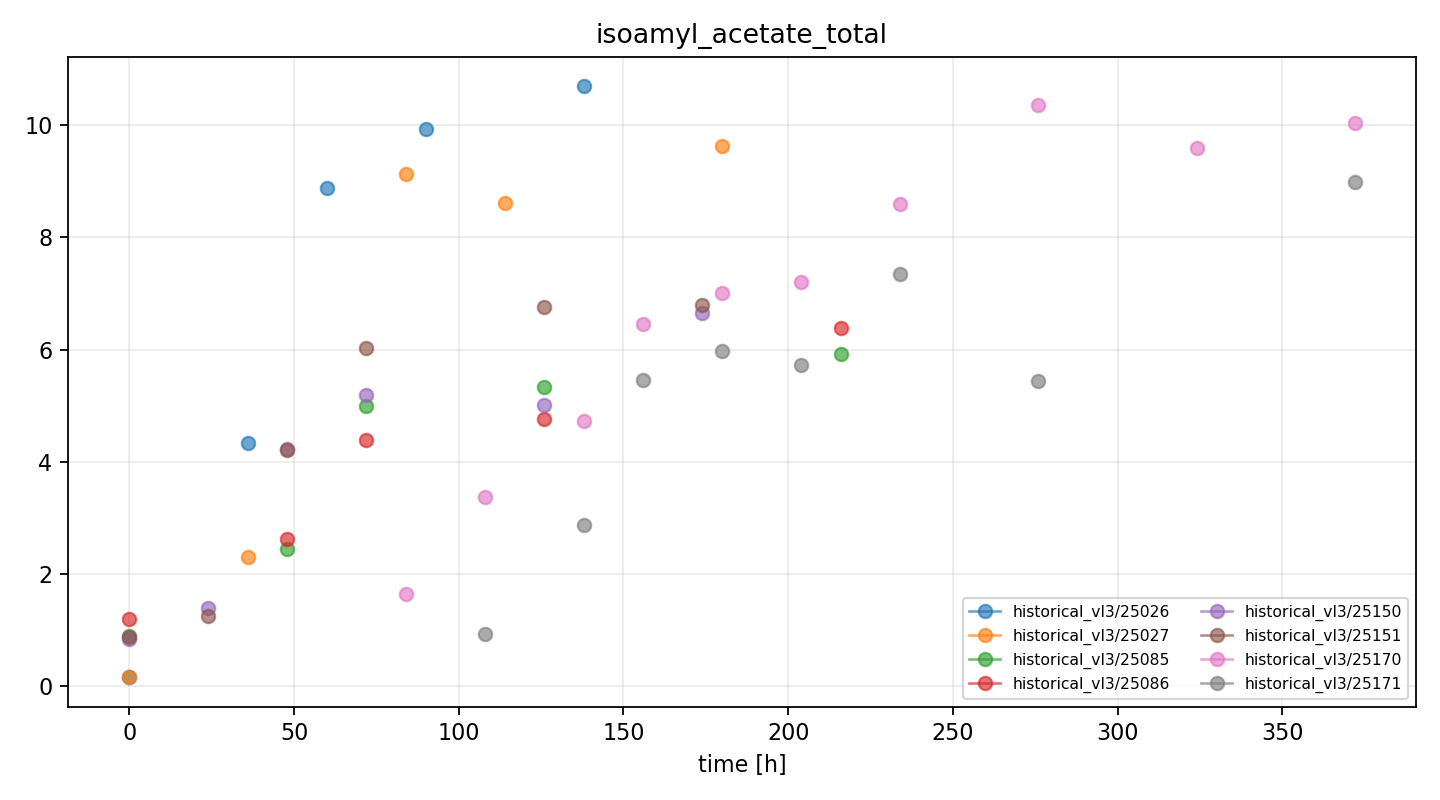

overlay_NH4_mg_l.png


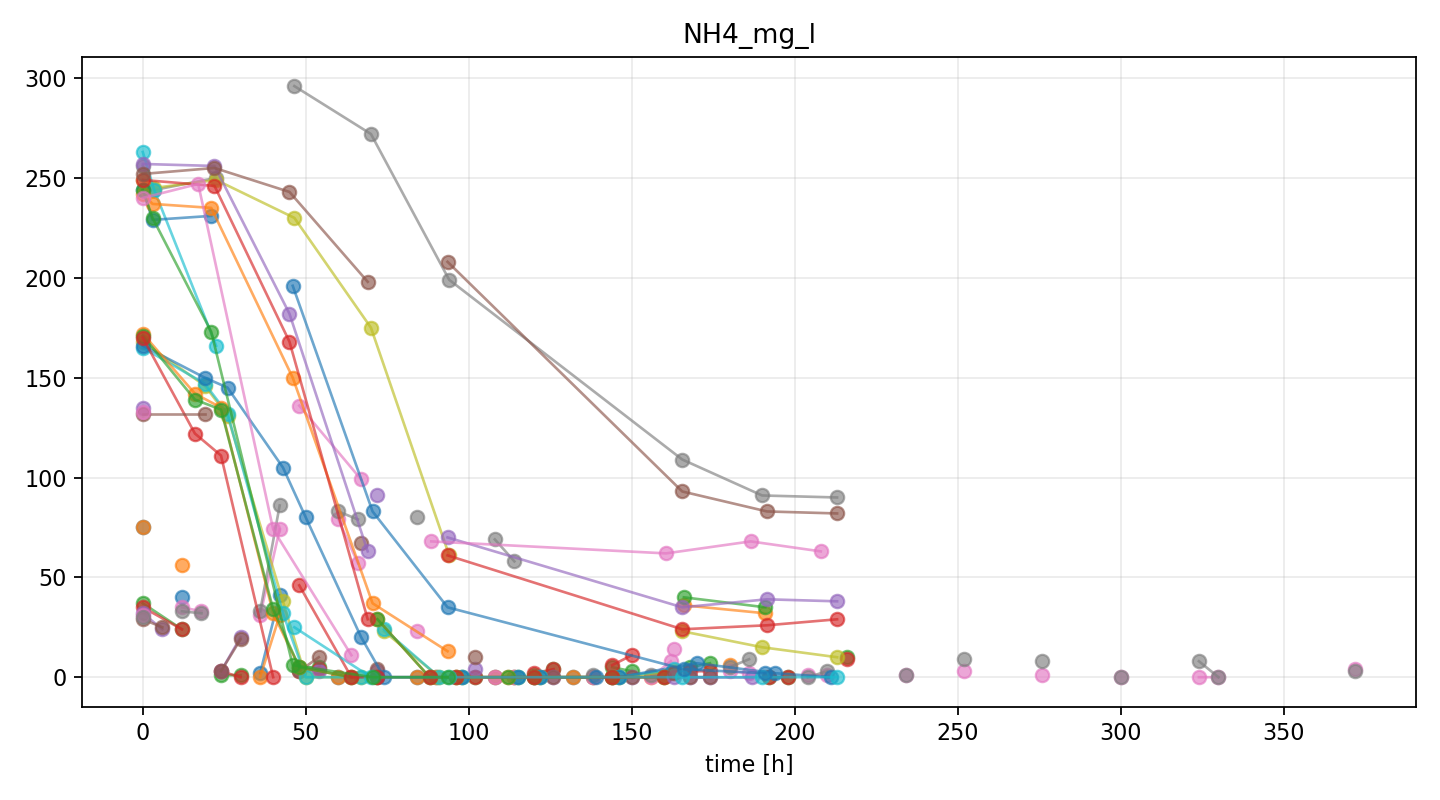

overlay_PAN_mg_l.png


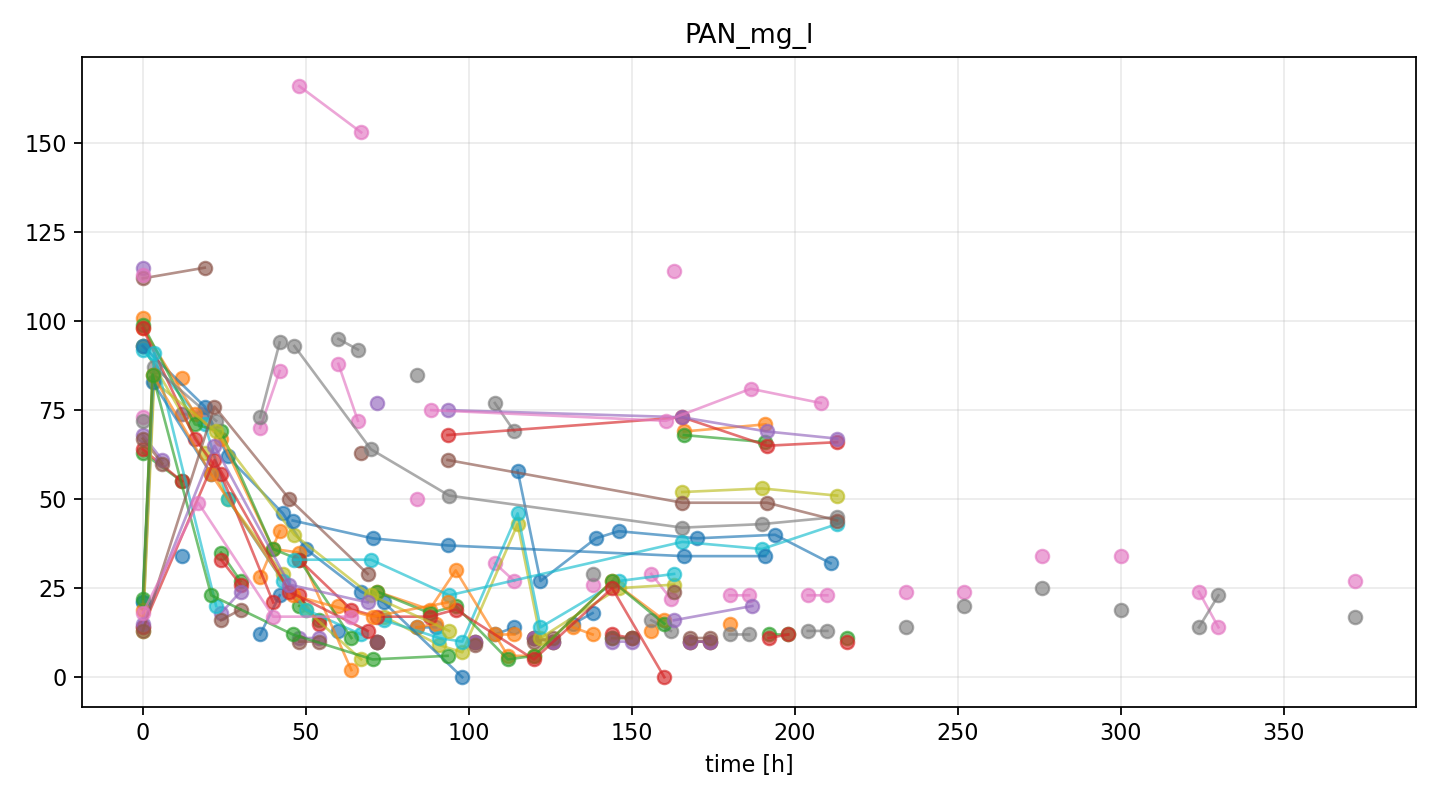

overlay_phenylethyl_acetate_total.png


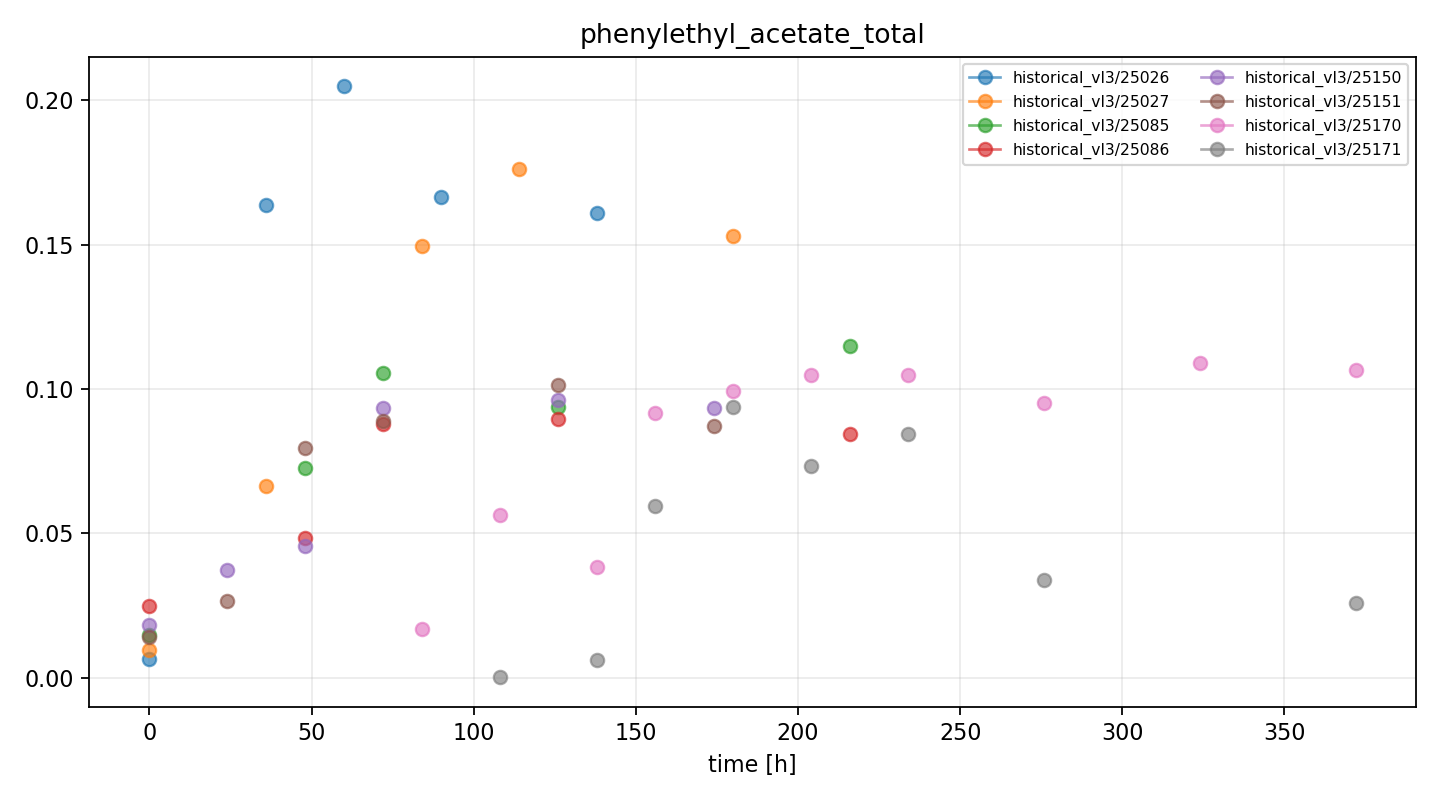

overlay_pyruvic_acid.png


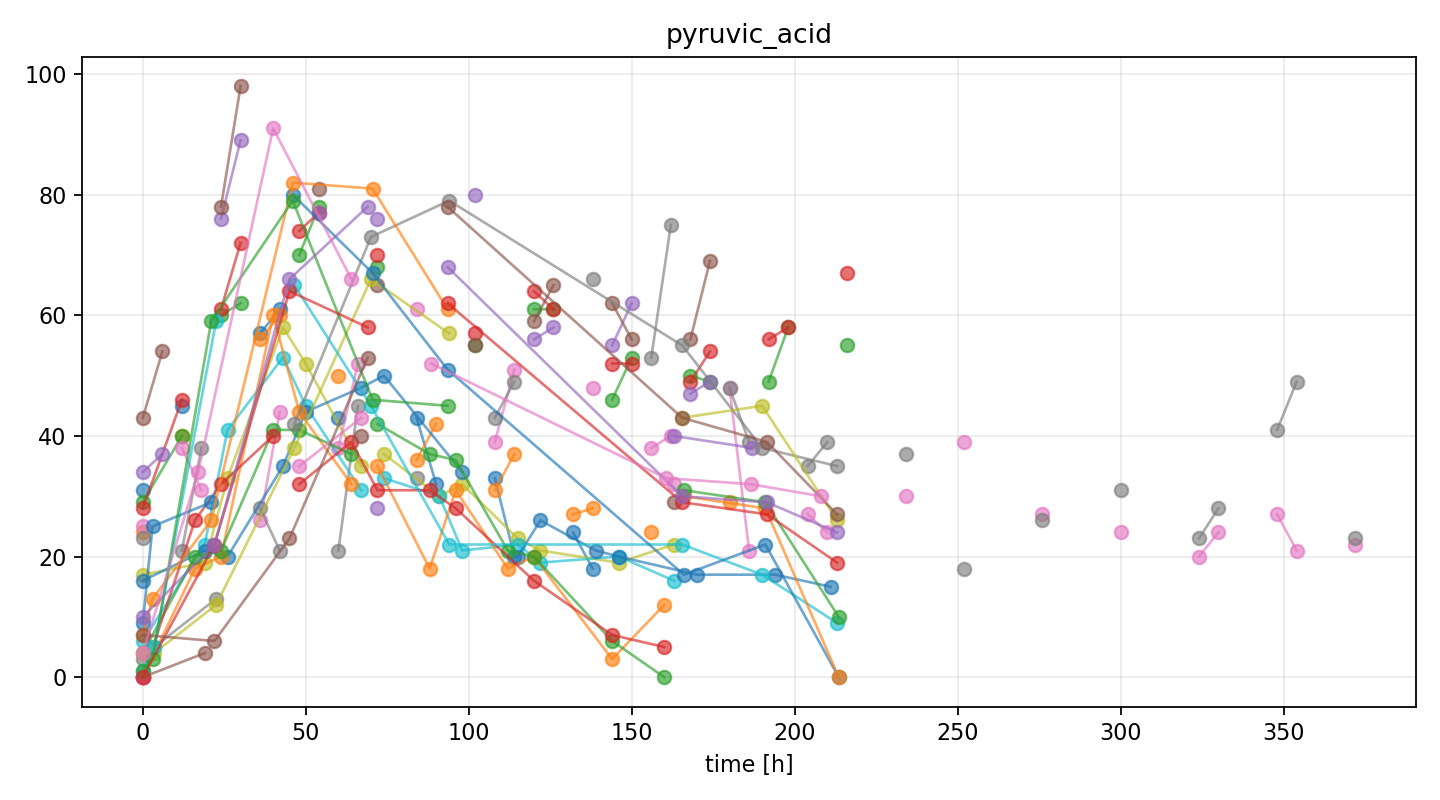

overlay_pyruvic_acid_2.png


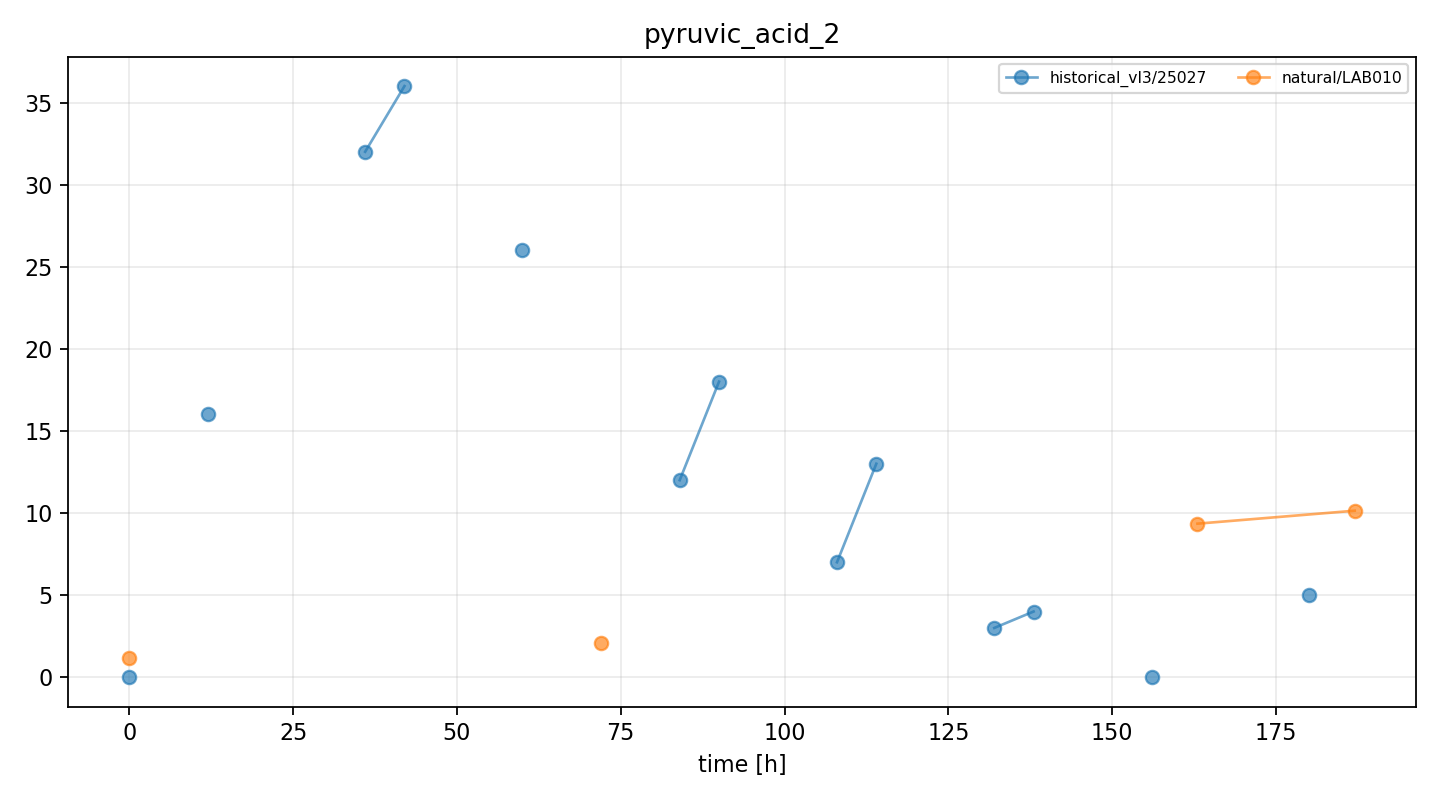

overlay_YAN_mg_l.png


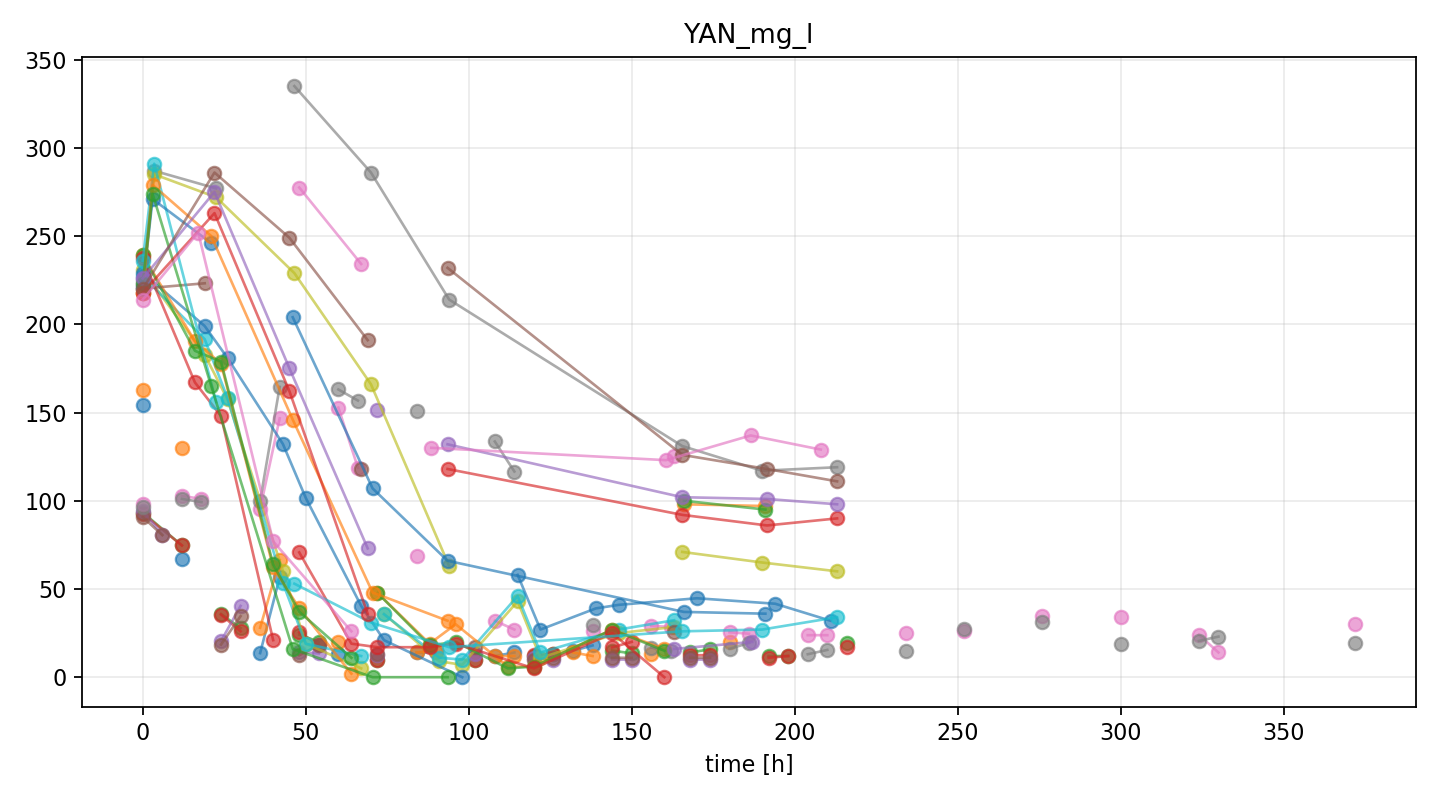

In [5]:
for png in sorted((RESULTS / 'plots').glob('overlay_*.png')):
    print(png.name)
    display(Image(filename=str(png)))

## Modeling notes

See `secondary_metabolite_modeling_notes.md` for the proposed ODE treatment of pyruvate, acetaldehyde, acetate, net liquid aroma outputs, and oxygen.

In [6]:
print((RESULTS / 'secondary_metabolite_modeling_notes.md').read_text(encoding='utf-8'))

# Secondary-metabolite modeling notes

## Data-driven interpretation

The review plots should be read as a model-structure diagnostic. A state is a good candidate for direct calibration only when it has repeated time trajectories, coverage over the phase where the state changes, and enough perturbation across media or inputs. A state should remain an auxiliary or regularized output when it is sparsely measured, mostly terminal, or confounded with an unmeasured loss process.

Current evidence supports adding pyruvate as a transient state. Acetaldehyde and acetic acid are also informative, but their dynamics should be coupled to redox and oxygen exposure instead of being fitted as independent Monod products. Liquid aromas should be treated as net liquid outputs unless gas or condensate measurements are available for the same experiment.

PAN and ammonium should not be collapsed blindly into a single nitrogen pool. A minimal upgrade is to keep two external nitrogen states and let the grow